# 8. k-nearest neighbours, naive Bayes and the curse of dimensionality

This notebook studies two of the oldest and simplest classifiers in machine learning —
and two of the most instructive. **$k$-nearest neighbours** ($k$NN) does not learn
anything at training time at all: it memorises the data and, when asked about a new point,
looks up the most similar training points and copies their labels. **Naive Bayes** learns
only a handful of per-feature statistics per class and combines them with Bayes' theorem
under a wildly over-simplified independence assumption. Neither method is the first thing
you would reach for in a modern project, yet both are strong baselines, both are in daily
use (recommendation, spam filtering, document classification), and both expose ideas that
run through the rest of the course:

- what "similar" means and why **feature scaling and the choice of distance** matter;
- the **bias–variance trade-off** in its purest form (the single knob $k$);
- why intuition about distances breaks down in many dimensions — the **curse of
  dimensionality** — which is the reason local methods struggle and the reason
  dimensionality reduction (notebook 14) exists;
- the difference between **generative** models (which describe how the data were produced)
  and **discriminative** models (which only describe the decision boundary), with logistic
  regression from notebook 7 as the discriminative twin of naive Bayes.

The last three sections are the ones you will come back to when you actually use these
methods: what each one is good and bad at, with two of its failures demonstrated
(section 7); how to tune them, with a validation curve for every parameter that matters
(section 8); and two complete applications — $k$NN on a real diagnostic dataset and
multinomial naive Bayes on a text corpus (section 9).

**Prerequisites:** notebook 2 (Bayes' theorem, maximum likelihood, Gaussians), notebook 4
(scaling, one-hot and text features), notebook 5 (cross-validation, learning curves) and
notebook 7 (logistic regression, calibration). Notebook 9 (decision trees) is independent
of this one.

## Learning objectives

After working through this notebook you will be able to

- implement $k$NN classification and regression from scratch with vectorised NumPy distance computations, and explain the roles of $k$, the distance metric, feature scaling and neighbour weighting;
- read a $k$NN decision boundary as a bias–variance trade-off and choose $k$ by cross-validation;
- state the Cover–Hart bound and explain why the 1-NN error is at most twice the Bayes error;
- explain the computational profile of a lazy learner (brute force vs. KD-trees / ball trees) and know when tree-based search stops helping;
- demonstrate the three faces of the curse of dimensionality (volume in the corners, distance concentration, sample complexity) by simulation and explain their consequences for local methods;
- derive and implement Gaussian naive Bayes, apply multinomial / Bernoulli naive Bayes to text with Laplace smoothing, and explain why naive Bayes is a linear classifier whose probabilities are badly calibrated;
- compare generative and discriminative classifiers with a learning-curve experiment and explain the Ng–Jordan result;
- connect $k$NN and kernel density estimation, and use neighbour distances as an anomaly score;
- state what $k$NN, Gaussian naive Bayes and multinomial naive Bayes assume, where each one breaks, and which to reach for on a given dataset;
- tune `n_neighbors`, `weights`, the metric, `var_smoothing` and `alpha` with validation curves, a 2-D cross-validation heat-map and the one-standard-error rule;
- carry a classification problem end to end on real data — scaling, tuning inside a pipeline, a confusion matrix and ROC curve on a held-out set, and an honest summary for a non-technical stakeholder.

## Setup

In [1]:
import time                        # time.perf_counter() is a high-resolution clock for timing code

import numpy as np                 # arrays and fast numerical maths
import pandas as pd                # DataFrames: labelled tables built on top of NumPy
import matplotlib.pyplot as plt    # the plotting library behind every figure in the course
import seaborn as sns              # statistical plots on top of matplotlib (imported, but not used in this notebook)
from scipy.stats import norm       # the normal distribution: norm.cdf (its CDF Φ) and norm.pdf (its density)
from scipy.special import gamma    # the Gamma function Γ, used in the volume of a d-dimensional ball

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# plot_decision_boundary(model, X, y, ...) shades the region a fitted 2-D classifier assigns to each class,
# load_reviews() returns the bundled (synthetic) product-review corpus with sentiment labels
from course_utils import set_style, PALETTE, plot_decision_boundary, load_reviews

RANDOM_STATE = 42                          # one fixed seed so every run produces the same results
rng = np.random.default_rng(RANDOM_STATE)  # a seeded random-number generator
set_style()                                # apply the course-wide matplotlib settings once

## 1. Instance-based learning: $k$-nearest neighbours

### 1.1 The idea

Suppose you want to guess the price of a flat. A sensible first approach is to look up a
few flats of similar size, age and location that were sold recently, and average their
prices. That is $k$-nearest-neighbour regression. If you want to predict whether a customer
will churn, look up the $k$ most similar past customers and take a majority vote among
them: $k$NN classification. The method rests on a single assumption — the **smoothness
assumption**: points that are close in feature space tend to have similar targets.

> **History.** Nearest-neighbour classification was proposed by Fix & Hodges (1951) in a
> technical report for the US Air Force that remained unpublished for almost forty years;
> Cover & Hart (1967) proved the error bound of section 1.5 that made the rule famous.

Formally, let $d(\cdot, \cdot)$ be a distance on $\mathbb{R}^d$ and let
$N_k(\mathbf{x}) \subseteq \{1, \dots, n\}$ be the indices of the $k$ training points
closest to a query $\mathbf{x}$. Then

$$
\hat{p}(y = c \mid \mathbf{x}) = \frac{1}{k} \sum_{i \in N_k(\mathbf{x})} \mathbb{1}[y_i = c],
\qquad
\hat{y}(\mathbf{x}) = \arg\max_c \hat{p}(y = c \mid \mathbf{x})
\qquad \text{(classification)},
$$

$$
\hat{y}(\mathbf{x}) = \frac{1}{k} \sum_{i \in N_k(\mathbf{x})} y_i
\qquad \text{(regression)}.
$$

The *weighted* variant replaces the uniform average by weights $w_i \propto 1/d(\mathbf{x}, \mathbf{x}_i)$,
so that closer neighbours count more. There are no parameters to fit: $k$NN is a
**non-parametric** method (the "model" *is* the training set) and a **lazy learner** —
all the work happens at prediction time. Its effective complexity is governed by $k$:
Hastie et al. (2009, §2.3) argue that a $k$NN fit behaves roughly like a model with
$n/k$ effective parameters, so $k = 1$ is the most flexible model imaginable and $k = n$
predicts the global majority everywhere.

### 1.2 Distances, and why scaling is essential

Everything hinges on the word *close*. The common choices for two vectors
$\mathbf{a}, \mathbf{b} \in \mathbb{R}^d$ are

| Distance | Formula | Notes |
|---|---|---|
| Euclidean ($\ell_2$) | $\|\mathbf{a} - \mathbf{b}\|_2 = \sqrt{\sum_j (a_j - b_j)^2}$ | the default; rotation-invariant |
| Manhattan ($\ell_1$) | $\|\mathbf{a} - \mathbf{b}\|_1 = \sum_j \lvert a_j - b_j \rvert$ | more robust to a single very different coordinate |
| Minkowski ($\ell_p$) | $\big(\sum_j \lvert a_j - b_j \rvert^p\big)^{1/p}$ | $p = 1, 2$ above; $p \to \infty$ gives the Chebyshev distance $\max_j \lvert a_j - b_j\rvert$ |
| Cosine distance | $1 - \dfrac{\mathbf{a}^\top \mathbf{b}}{\|\mathbf{a}\|_2 \|\mathbf{b}\|_2}$ | ignores the length of the vectors; the standard choice for text and embeddings |

Every one of these adds up per-feature differences, so a feature measured in large units
dominates a feature measured in small units *purely because of its units*. If one column
is annual income in dollars (spread ~ 50 000) and another is the number of children
(spread ~ 2), the second column is effectively ignored. $k$NN therefore needs features on
comparable scales: `StandardScaler` (or `MinMaxScaler`) *inside a pipeline*, as notebook 4
prescribes. The wine data (13 chemical measurements with wildly different ranges — proline
is in the hundreds, hue is around 1) shows how much this matters.

In [2]:
from sklearn.datasets import load_wine                   # 178 wines, 13 chemical measurements, 3 cultivars
from sklearn.neighbors import KNeighborsClassifier       # scikit-learn's kNN classifier
from sklearn.preprocessing import StandardScaler         # rescales every feature to mean 0 and standard deviation 1
from sklearn.pipeline import make_pipeline               # chains preprocessing steps and a model into one estimator
# cross_val_score: one score per CV fold | StratifiedKFold: k-fold splits that keep the class proportions in every fold
from sklearn.model_selection import cross_val_score, StratifiedKFold

wine = load_wine(as_frame=True)                 # as_frame=True: .data is a DataFrame, .target a Series
X_wine, y_wine = wine.data, wine.target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # 5 folds, rows shuffled reproducibly

print("feature ranges (min – max) of three wine features:")
for col in ["proline", "hue", "magnesium"]:
    # :10s pads the name to 10 characters; :8.2f prints a number 8 characters wide with 2 decimals
    print(f"  {col:10s} {X_wine[col].min():8.2f} – {X_wine[col].max():8.2f}")

# without a scoring argument, cross_val_score uses the model's own .score: accuracy for a classifier
raw = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_wine, y_wine, cv=cv)
# the scaler is part of the pipeline, so in every fold it is fitted on that fold's training rows only
scaled = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)), X_wine, y_wine, cv=cv)
print(f"\n5-NN CV accuracy on raw features:          {raw.mean():.3f}")
print(f"5-NN CV accuracy on standardised features: {scaled.mean():.3f}")

feature ranges (min – max) of three wine features:
  proline      278.00 –  1680.00
  hue            0.48 –     1.71
  magnesium     70.00 –   162.00

5-NN CV accuracy on raw features:          0.680
5-NN CV accuracy on standardised features: 0.972


> **Warning.** Unscaled $k$NN is one of the most common beginner mistakes, and the
> symptom — mediocre accuracy — gives no hint of the cause. The same applies to every
> distance-based method: $k$-means (notebook 13), SVMs (notebook 11), PCA (notebook 14).
> Trees (notebook 9) are the exception: they are invariant to monotone rescaling.

### 1.3 $k$NN from scratch

The only computational ingredient is the matrix of distances between $n_q$ query points
and $n$ training points. Rather than looping, we use the identity

$$
\|\mathbf{a} - \mathbf{b}\|_2^2 = \|\mathbf{a}\|_2^2 + \|\mathbf{b}\|_2^2 - 2\,\mathbf{a}^\top \mathbf{b},
$$

which turns the whole $n_q \times n$ matrix of squared distances into one matrix product
plus two broadcasts (notebook 1). Then `np.argpartition` finds the $k$ smallest entries of
each row in $O(n)$ time without fully sorting the row. Votes are counted per class;
`np.argmax` returns the *first* maximal class, so ties are broken in favour of the smallest
label — the same convention as scikit-learn. (With an odd $k$ there are no ties in binary
problems, which is why $k = 5$ is a more popular default than $k = 4$.)

In [3]:
def pairwise_sq_dists(A, B):
    """Squared Euclidean distances between the rows of A (n_q x d) and the rows of B (n x d).

    Returns an (n_q, n) array D with D[i, j] = ||A[i] - B[j]||^2, computed as ||a||^2 + ||b||^2 - 2 a.b.
    """
    # (n_q, 1) + (1, n) - (n_q, n): the two squared-norm vectors broadcast against the matrix product
    sq = (A ** 2).sum(axis=1)[:, None] + (B ** 2).sum(axis=1)[None, :] - 2.0 * A @ B.T
    return np.maximum(sq, 0.0)          # clip tiny negative values caused by rounding


class KNNClassifierScratch:
    """k-nearest-neighbour classifier with Euclidean distance (uniform or 1/distance weights)."""

    def __init__(self, k=5, weights="uniform"):
        """Store the settings: k neighbours, weights "uniform" (one vote each) or anything else for 1/distance."""
        self.k, self.weights = k, weights

    def fit(self, X, y):
        """Memorise the training data X (n, d) and labels y; returns self so calls can be chained."""
        self.X_, self.y_ = np.asarray(X, dtype=float), np.asarray(y)
        self.classes_ = np.unique(self.y_)            # the sorted distinct labels
        return self                                   # nothing to learn: just store the data

    def _neighbour_weights(self, X):
        """For every query row of X, return the indices of its k nearest training points and their weights.

        Both returned arrays have shape (n_queries, k).
        """
        d2 = pairwise_sq_dists(np.asarray(X, dtype=float), self.X_)     # (n_queries, n_train)
        # np.argpartition(a, k - 1) moves the k smallest entries of each row into the first k positions
        # (in no particular order) without sorting the rest; [:, : self.k] keeps those k column indices
        idx = np.argpartition(d2, self.k - 1, axis=1)[:, : self.k]      # indices of the k closest
        if self.weights == "uniform":
            w = np.ones(idx.shape)
        else:                                          # 1/distance; a zero distance gets all the weight
            dist = np.sqrt(np.take_along_axis(d2, idx, axis=1))   # take_along_axis: d2[i, idx[i, j]] for every i, j
            # rows that contain an exact match: weight 1 for the zero-distance neighbours and 0 for the others;
            # all other rows: 1 / distance (the floor 1e-12 only avoids a division by zero)
            w = np.where((dist == 0).any(axis=1, keepdims=True), (dist == 0).astype(float), 1.0 / np.maximum(dist, 1e-12))
        return idx, w

    def predict_proba(self, X):
        """Class probabilities, shape (n_queries, n_classes): each class's share of the (weighted) votes."""
        idx, w = self._neighbour_weights(X)
        # self.y_[idx] are the neighbours' labels; searchsorted finds each label's position in the sorted classes_
        labels = np.searchsorted(self.classes_, self.y_[idx])          # class index of every neighbour
        proba = np.zeros((len(idx), len(self.classes_)))
        for c in range(len(self.classes_)):
            proba[:, c] = (w * (labels == c)).sum(axis=1)             # (weighted) vote count per class
        return proba / proba.sum(axis=1, keepdims=True)               # turn vote counts into shares that sum to 1

    def predict(self, X):
        """The class with the most (weighted) votes; ties go to the smaller label, because argmax picks the first."""
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class KNNRegressorScratch(KNNClassifierScratch):
    """k-nearest-neighbour regression: (weighted) mean of the neighbours' targets.

    Inherits __init__, fit and _neighbour_weights from the classifier and replaces only predict.
    """

    def predict(self, X):
        """The (weighted) average of the k nearest training targets, one value per query row."""
        idx, w = self._neighbour_weights(X)
        return (w * self.y_[idx]).sum(axis=1) / w.sum(axis=1)

We check both against scikit-learn: the classifier on the "two moons" data from notebook 5,
the regressor on a noisy sine curve.

In [4]:
from sklearn.datasets import make_moons                  # two interleaving half-circles, one per class
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split     # splits arrays into random train and test parts

# noise: standard deviation of the Gaussian noise added to the points
X_moons, y_moons = make_moons(n_samples=400, noise=0.3, random_state=RANDOM_STATE)
# half for training, half for testing; stratify keeps the class proportions equal in both halves
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_moons, y_moons, test_size=0.5, stratify=y_moons,
                                                        random_state=RANDOM_STATE)
for k in [1, 5, 15]:
    for weights in ["uniform", "distance"]:
        ours = KNNClassifierScratch(k, weights).fit(Xm_train, ym_train)
        theirs = KNeighborsClassifier(n_neighbors=k, weights=weights).fit(Xm_train, ym_train)
        agree = np.mean(ours.predict(Xm_test) == theirs.predict(Xm_test))     # fraction of identical predictions
        max_diff = np.abs(ours.predict_proba(Xm_test) - theirs.predict_proba(Xm_test)).max()
        # :2d pads an integer to 2 characters, :8s a string to 8; :.1e is scientific notation with 1 decimal
        print(f"k={k:2d} weights={weights:8s} predictions agree: {agree:.3f}   max |Δ proba| = {max_diff:.1e}")

x_reg = np.sort(rng.uniform(0, 1, 80))                       # 80 sorted x-values in [0, 1)
y_reg = np.sin(2 * np.pi * x_reg) + rng.normal(0, 0.3, 80)   # a sine curve plus noise with standard deviation 0.3
x_grid = np.linspace(0, 1, 400)[:, None]                     # (400, 1): scikit-learn expects a 2-D X
ours_reg = KNNRegressorScratch(k=5).fit(x_reg[:, None], y_reg).predict(x_grid)
theirs_reg = KNeighborsRegressor(n_neighbors=5).fit(x_reg[:, None], y_reg).predict(x_grid)
print(f"\nregression: max |Δ prediction| between our kNN and KNeighborsRegressor = {np.abs(ours_reg - theirs_reg).max():.1e}")

k= 1 weights=uniform  predictions agree: 1.000   max |Δ proba| = 0.0e+00
k= 1 weights=distance predictions agree: 1.000   max |Δ proba| = 0.0e+00
k= 5 weights=uniform  predictions agree: 1.000   max |Δ proba| = 0.0e+00
k= 5 weights=distance predictions agree: 1.000   max |Δ proba| = 5.5e-14
k=15 weights=uniform  predictions agree: 1.000   max |Δ proba| = 0.0e+00
k=15 weights=distance predictions agree: 1.000   max |Δ proba| = 2.6e-13

regression: max |Δ prediction| between our kNN and KNeighborsRegressor = 0.0e+00


The regressor shows the *shape* of a $k$NN fit: a piecewise-constant function (the average
jumps whenever the neighbour set changes), rough for small $k$ and over-smoothed for large
$k$. This is the bias–variance trade-off of notebook 5 with a single knob.

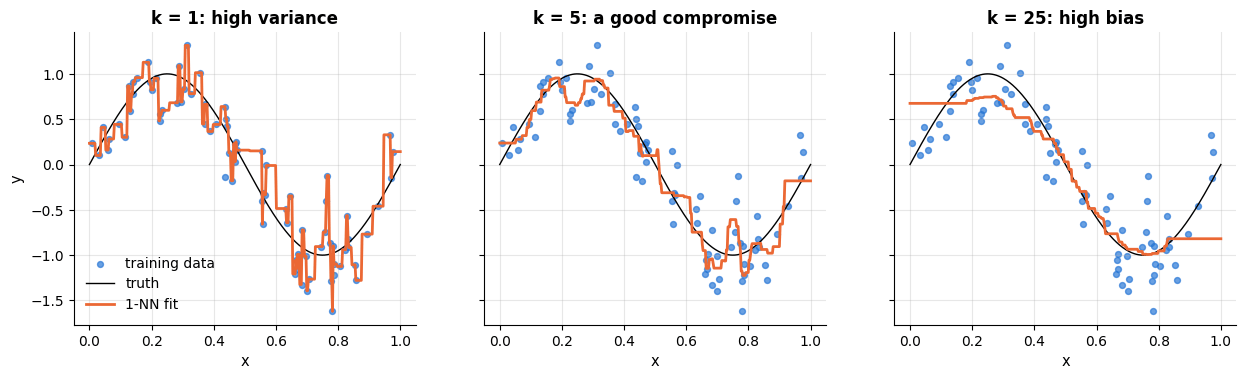

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)    # sharey: all panels use the same y-axis
for ax, k in zip(axes, [1, 5, 25]):
    fit = KNeighborsRegressor(n_neighbors=k).fit(x_reg[:, None], y_reg)
    ax.scatter(x_reg, y_reg, s=18, color=PALETTE[0], alpha=0.7, label="training data")
    # x_grid[:, 0] turns the (400, 1) column back into a 1-D array for plotting
    ax.plot(x_grid[:, 0], np.sin(2 * np.pi * x_grid[:, 0]), color="black", lw=1, label="truth")
    ax.plot(x_grid[:, 0], fit.predict(x_grid), color=PALETTE[1], lw=2, label=f"{k}-NN fit")
    # a chained conditional: "high variance" for k = 1, "high bias" for k = 25, otherwise "a good compromise"
    ax.set_title(f"k = {k}: " + ("high variance" if k == 1 else "high bias" if k == 25 else "a good compromise"))
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="lower left")
plt.show()

### 1.4 Decision boundaries and the choice of $k$

For classification the same trade-off shows up in the shape of the decision boundary.
With $k = 1$ every training point owns a little cell (a *Voronoi* cell) and the boundary
follows every noise point; with large $k$ the boundary is smooth but ignores real
structure.

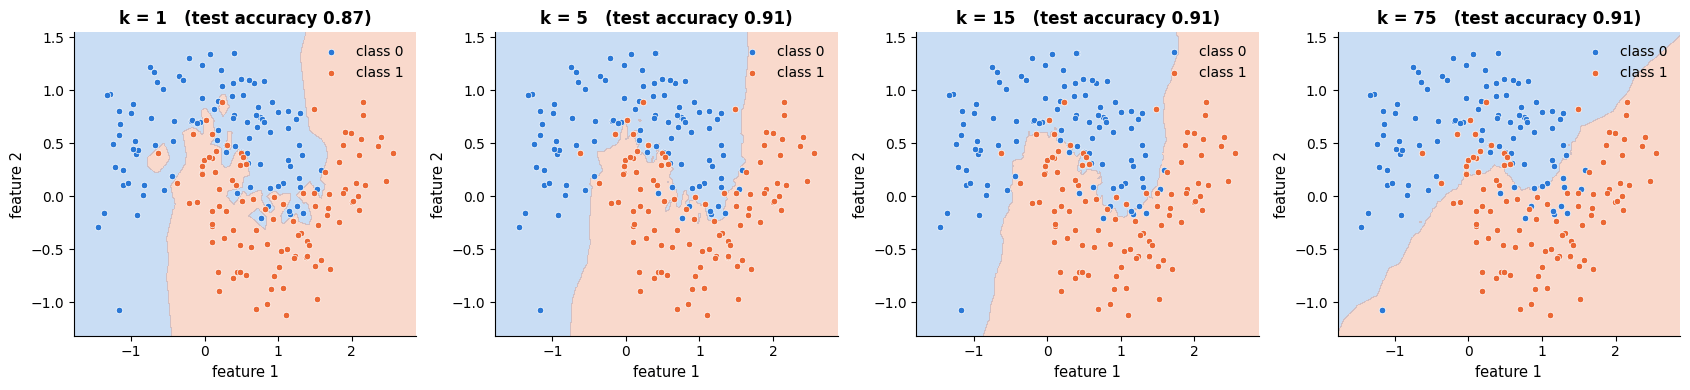

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, k in zip(axes, [1, 5, 15, 75]):
    clf = KNeighborsClassifier(n_neighbors=k).fit(Xm_train, ym_train)
    acc = clf.score(Xm_test, ym_test)                 # .score(X, y): accuracy on the test half
    # the regions are drawn over the training points
    plot_decision_boundary(clf, Xm_train, ym_train, ax=ax, title=f"k = {k}   (test accuracy {acc:.2f})")
plt.tight_layout()
plt.show()

The right way to pick $k$ is cross-validation (notebook 5); note that model complexity
*decreases* as $k$ grows, so the plot below is the usual complexity curve read from right
to left. We also add the ± 1 standard-error band and apply the one-standard-error rule
(choose the *largest* $k$ within one SE of the best — the simplest model that is not
measurably worse).

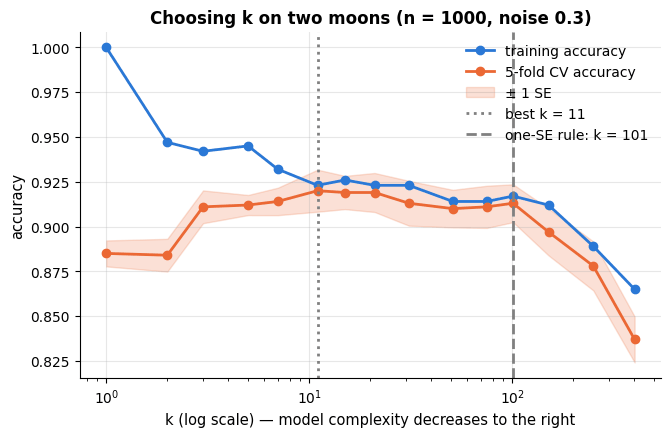

best CV accuracy 0.920 at k = 11; one-SE choice k = 101 (0.913)


In [7]:
X_big, y_big = make_moons(n_samples=1000, noise=0.3, random_state=RANDOM_STATE)
ks = np.array([1, 2, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101, 151, 251, 401])     # a roughly log-spaced grid of k
train_acc, cv_mean, cv_se = [], [], []
for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_big, y_big, cv=cv)                # 5 fold accuracies
    cv_mean.append(scores.mean())
    cv_se.append(scores.std(ddof=1) / np.sqrt(len(scores)))           # standard error; ddof=1: sample std
    train_acc.append(clf.fit(X_big, y_big).score(X_big, y_big))       # accuracy on the data it was fitted on
cv_mean, cv_se = np.array(cv_mean), np.array(cv_se)

best = int(np.argmax(cv_mean))                    # position of the best k in ks
# np.where(condition) returns a tuple holding the positions where it is True; np.max takes the largest of them
one_se = int(np.max(np.where(cv_mean >= cv_mean[best] - cv_se[best])))   # largest k within one SE of the best
fig, ax = plt.subplots()
ax.plot(ks, train_acc, marker="o", label="training accuracy")
ax.plot(ks, cv_mean, marker="o", label="5-fold CV accuracy")
# fill_between(x, lower, upper) shades the band between two curves: here mean ± 1 SE
ax.fill_between(ks, cv_mean - cv_se, cv_mean + cv_se, alpha=0.2, color=PALETTE[1], label="± 1 SE")
ax.axvline(ks[best], color="gray", ls=":", label=f"best k = {ks[best]}")
ax.axvline(ks[one_se], color="gray", ls="--", label=f"one-SE rule: k = {ks[one_se]}")
ax.set_xscale("log")
ax.set_xlabel("k (log scale) — model complexity decreases to the right")
ax.set_ylabel("accuracy")
ax.set_title("Choosing k on two moons (n = 1000, noise 0.3)")
ax.legend()
plt.show()
print(f"best CV accuracy {cv_mean[best]:.3f} at k = {ks[best]}; one-SE choice k = {ks[one_se]} ({cv_mean[one_se]:.3f})")

> **Key idea.** $k$ is a smoothing parameter. Small $k$: low bias, high variance, jagged
> boundary, training accuracy 100 % at $k = 1$. Large $k$: high bias, low variance, tends to
> the majority class. Choose it by cross-validation, and prefer the one-SE choice when the
> curve is flat.

### 1.5 How good can nearest neighbours be? The Cover–Hart bound

Cover & Hart (1967) proved a remarkable fact about the simplest version, $k = 1$. Let
$R^\star$ be the Bayes error (notebook 5: the error of the best possible classifier) and
$R_{1\text{NN}}$ the error of the 1-NN rule in the limit of infinitely many training
points. Then, for two classes,

$$
R^\star \;\le\; R_{1\text{NN}} \;\le\; 2 R^\star (1 - R^\star) \;\le\; 2 R^\star .
$$

**Why.** With infinitely many training points, the nearest neighbour of a query
$\mathbf{x}$ sits at (essentially) the same location, so its label is an independent draw
from the same posterior $p = P(y = 1 \mid \mathbf{x})$ as the query's own label. The 1-NN
rule errs when the two draws disagree: probability $p(1-p) + (1-p)p = 2p(1-p)$. The Bayes
rule errs with probability $r(\mathbf{x}) = \min(p, 1-p)$, and $2p(1-p) = 2r(1-r) \le 2r$.
Averaging over $\mathbf{x}$ (and using Jensen's inequality for the middle term) gives the
bound. For $K$ classes the middle term becomes $R^\star\big(2 - \tfrac{K}{K-1} R^\star\big)$.

The message is striking: *half of all the information in an infinite training set is
contained in the single nearest neighbour*. The catch is the word "infinite" — in high
dimensions the nearest neighbour is nowhere near the query (section 3). Let us verify the
bound by simulation on a problem whose Bayes error we know exactly: two Gaussian classes
in $\mathbb{R}^2$ with identity covariance and means $\Delta$ apart, for which
$R^\star = \Phi(-\Delta/2)$ (notebook 2), where $\Phi$ is the standard normal CDF.

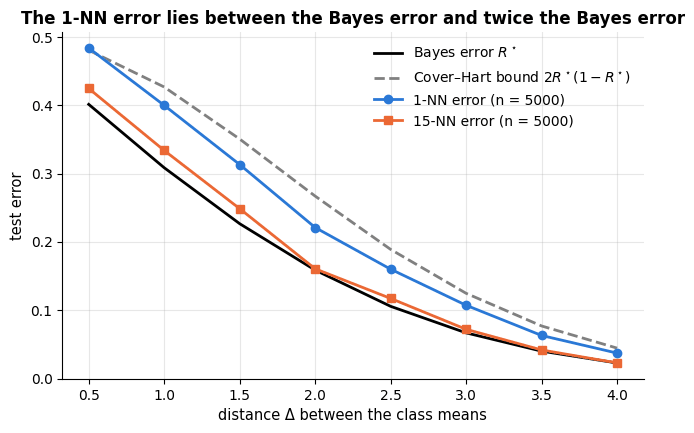

,Δ,Bayes error,1-NN error,15-NN error,bound 2R*(1-R*)
0,0.5,0.401,0.484,0.425,0.481
1,1.0,0.309,0.400,0.334,0.427
2,1.5,0.227,0.313,0.249,0.351
3,2.0,0.159,0.221,0.161,0.267
4,2.5,0.106,0.160,0.117,0.189
5,3.0,0.067,0.107,0.072,0.125
6,3.5,0.040,0.063,0.042,0.077
7,4.0,0.023,0.037,0.023,0.044


In [8]:
def two_gaussians(n, delta, d=2):
    """Two equiprobable Gaussian classes N(0, I) and N(delta * e_1, I).

    Returns X of shape (n, d) and labels y in {0, 1}; class-1 points are shifted by delta along the first axis.
    """
    y = rng.integers(0, 2, n)            # random labels 0 or 1 (the upper bound 2 is excluded)
    X = rng.normal(size=(n, d))          # standard-normal points
    X[:, 0] += delta * y                 # shift the first coordinate of the class-1 points only
    return X, y

deltas = np.linspace(0.5, 4.0, 8)        # 0.5, 1.0, ..., 4.0
rows = []
for delta in deltas:
    Xa, ya = two_gaussians(5000, delta)          # training sample
    Xb, yb = two_gaussians(5000, delta)          # independent test sample
    bayes = norm.cdf(-delta / 2)                 # the exact Bayes error Φ(-Δ/2)
    # error = 1 - accuracy on the test sample
    err_1nn = 1 - KNeighborsClassifier(n_neighbors=1).fit(Xa, ya).score(Xb, yb)
    err_15nn = 1 - KNeighborsClassifier(n_neighbors=15).fit(Xa, ya).score(Xb, yb)
    rows.append({"Δ": delta, "Bayes error": bayes, "1-NN error": err_1nn, "15-NN error": err_15nn,
                 "bound 2R*(1-R*)": 2 * bayes * (1 - bayes)})
cover_hart = pd.DataFrame(rows)                  # a list of dicts becomes one row per dict

fig, ax = plt.subplots()
ax.plot(deltas, cover_hart["Bayes error"], color="black", lw=2, label="Bayes error $R^\\star$")
ax.plot(deltas, cover_hart["bound 2R*(1-R*)"], color="gray", ls="--", lw=2, label="Cover–Hart bound $2R^\\star(1-R^\\star)$")
ax.plot(deltas, cover_hart["1-NN error"], marker="o", label="1-NN error (n = 5000)")
ax.plot(deltas, cover_hart["15-NN error"], marker="s", label="15-NN error (n = 5000)")
ax.set_xlabel("distance Δ between the class means")
ax.set_ylabel("test error")
ax.set_title("The 1-NN error lies between the Bayes error and twice the Bayes error")
ax.legend()
plt.show()
cover_hart.round(3)

The 1-NN error sits squarely between $R^\star$ and $2R^\star(1-R^\star)$, and 15-NN is
close to the Bayes error itself: with $k \to \infty$ and $k/n \to 0$ the $k$NN rule is
*universally consistent* — its error converges to the Bayes error for *any* distribution
(Stone, 1977). No assumption about the shape of the boundary is needed, which is the great
strength of the method; the price, again, is the amount of data required in high
dimensions.

## 2. Computational aspects: the price of laziness

Training a $k$NN model costs nothing (store the data: $O(nd)$ memory), but every
prediction with brute-force search costs $O(nd)$ distance computations, i.e.
$O(n_q\, n\, d)$ for $n_q$ queries — the *opposite* profile from a parametric model such as
logistic regression, which is expensive to fit and trivial to apply. With a million
training points and a thousand features, a single prediction is a billion operations. Two
families of remedies exist:

- **Space-partitioning trees.** A **KD-tree** (Bentley, 1975) recursively splits the data
  along coordinate axes; a query descends to a leaf and then backtracks, pruning any branch
  whose bounding box is further away than the $k$-th best distance found so far. A
  **ball tree** uses nested hyperspheres instead of boxes, which prunes better when $d$ is
  moderate. Both are built in $O(n \log n)$ and answer queries in $O(\log n)$ — *in low
  dimensions*. As $d$ grows, the bounding regions overlap more and more, pruning fails, and
  the query time degrades to $O(n)$ or worse (another face of the curse of
  dimensionality). scikit-learn's `algorithm="auto"` picks a tree for small $d$ and brute
  force otherwise.
- **Approximate nearest neighbours.** Modern vector databases give up exactness for speed:
  locality-sensitive hashing, product quantisation (FAISS), random projection forests
  (Annoy) and navigable small-world graphs (HNSW; Malkov & Yashunin, 2020) find
  neighbours in milliseconds among billions of vectors — this is what powers
  embedding-based search and retrieval-augmented generation.

The experiment below measures fit and query time of the three exact algorithms in
scikit-learn for $d = 2$ and $d = 64$ (timings will vary from machine to machine, but the
pattern is robust).

In [9]:
n_train, n_query = 20_000, 2_000          # underscores in numbers are only for readability
rows = []
for d in [2, 8, 64]:
    X_tr = rng.normal(size=(n_train, d)); y_tr = rng.integers(0, 2, n_train)     # ; separates two statements
    X_q = rng.normal(size=(n_query, d))
    # algorithm= picks how neighbours are searched: "brute" compares with every training point,
    # "kd_tree" and "ball_tree" build a search tree in .fit (section 2); all three give the same neighbours
    for algorithm in ["brute", "kd_tree", "ball_tree"]:
        t0 = time.perf_counter()
        clf = KNeighborsClassifier(n_neighbors=5, algorithm=algorithm).fit(X_tr, y_tr)
        t_fit = time.perf_counter() - t0                  # elapsed seconds
        t0 = time.perf_counter()
        clf.predict(X_q)
        t_query = time.perf_counter() - t0
        rows.append({"d": d, "algorithm": algorithm, "fit (ms)": 1000 * t_fit, "query 2000 points (ms)": 1000 * t_query})
# .pivot reshapes the long table into one row per algorithm and one column per d, filled with the query times
timing = pd.DataFrame(rows).pivot(index="algorithm", columns="d", values="query 2000 points (ms)")
print("query time in ms for 2000 queries against 20 000 training points:")
timing.round(1)

query time in ms for 2000 queries against 20 000 training points:


d,2,8,64
algorithm,,,
ball_tree,23.6,333.3,2987.5
brute,68.4,69.1,123.4
kd_tree,4.9,134.7,4162.5


In two dimensions the KD-tree answers queries an order of magnitude faster than brute
force; at $d = 64$ both trees are dramatically *slower* than brute force, because pruning
no longer works and the brute-force matrix product is extremely well optimised.

> **Practical guidance.** $k$NN is a fine choice when $n$ is moderate (up to ~$10^5$), $d$
> is small after scaling/PCA, and predictions are not latency-critical. For large $n$ use
> approximate search; for large $d$ reduce dimensionality first (notebook 14) or switch to a
> parametric model. Always scale; try $k \in \{1, 3, 5, 7, 11, 15, 21, 31, 51\}$ and
> `weights="distance"` by cross-validation; use `metric="cosine"` for text and embeddings.

## 3. The curse of dimensionality

The phrase is Bellman's (1961), coined for dynamic programming, and it now names a
collection of counter-intuitive facts about high-dimensional spaces. Three of them matter
for us.

### 3.1 The volume is in the corners (and in the shell)

Take the unit cube $[0, 1]^d$ and ask what fraction of its volume lies within $\varepsilon$
of its boundary. The interior cube has side $1 - 2\varepsilon$, so the boundary shell has
volume $1 - (1 - 2\varepsilon)^d$, which tends to 1 as $d$ grows: *almost all of a
high-dimensional cube is skin*. Similarly, the ball inscribed in the cube (radius $1/2$)
has volume $V_d = \pi^{d/2} (1/2)^d / \Gamma(d/2 + 1)$, a vanishing fraction of the cube:
uniformly distributed points are almost surely in the corners, far from the centre and far
from each other.

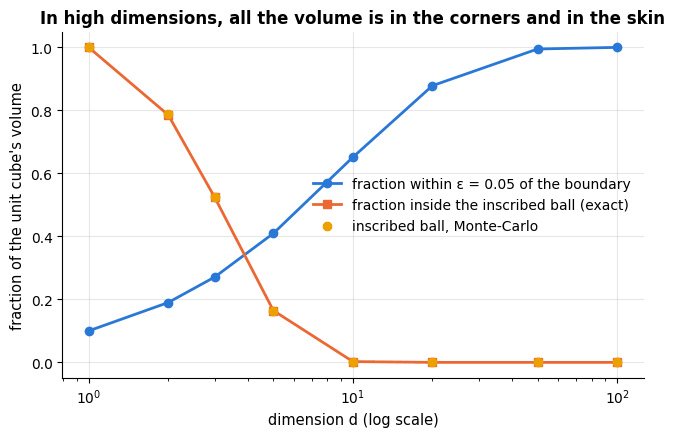

inscribed-ball fraction: d = 2 → 0.785, d = 10 → 0.0025, d = 20 → 2.46e-08


In [10]:
dims = np.array([1, 2, 3, 5, 10, 20, 50, 100])
eps = 0.05
shell = 1 - (1 - 2 * eps) ** dims                                # volume within eps of the boundary, one value per d
ball = np.pi ** (dims / 2) * 0.5 ** dims / gamma(dims / 2 + 1)   # volume of the inscribed ball (radius 1/2)
# Monte-Carlo check of the inscribed-ball fraction with 100 000 uniform points
# (a point is inside the ball when its distance from the cube's centre (0.5, ..., 0.5) is at most 0.5)
ball_mc = [np.mean(np.linalg.norm(rng.uniform(size=(100_000, d)) - 0.5, axis=1) <= 0.5) for d in dims]

fig, ax = plt.subplots()
ax.plot(dims, shell, marker="o", label=f"fraction within ε = {eps} of the boundary")
ax.plot(dims, ball, marker="s", label="fraction inside the inscribed ball (exact)")
ax.scatter(dims, ball_mc, color=PALETTE[3], zorder=3, label="inscribed ball, Monte-Carlo")   # zorder=3: draw on top
ax.set_xscale("log")
ax.set_xlabel("dimension d (log scale)")
ax.set_ylabel("fraction of the unit cube's volume")
ax.set_title("In high dimensions, all the volume is in the corners and in the skin")
ax.legend()
plt.show()
# str.format fills the {} placeholders in order; ball[1], ball[4], ball[5] belong to d = 2, 10 and 20
print("inscribed-ball fraction: d = 2 → {:.3f}, d = 10 → {:.4f}, d = 20 → {:.2e}".format(ball[1], ball[4], ball[5]))

### 3.2 Distances concentrate

Beyer et al. (1999) asked *when is "nearest neighbour" meaningful?* and answered: only if
the distance to the nearest point is noticeably smaller than the distance to the farthest.
For a query $\mathbf{q}$ and $n$ random points, define the **relative contrast**
$(d_{\max} - d_{\min}) / d_{\min}$. If the coordinates are i.i.d., a squared distance
$\|\mathbf{x} - \mathbf{q}\|^2 = \sum_{j=1}^d (x_j - q_j)^2$ is a sum of $d$ i.i.d. terms,
so its mean grows like $d$ while its standard deviation grows only like $\sqrt{d}$: the
*relative* spread of distances shrinks like $1/\sqrt{d}$, all points become almost
equidistant from the query, and the "nearest" neighbour is nearest by a whisker.

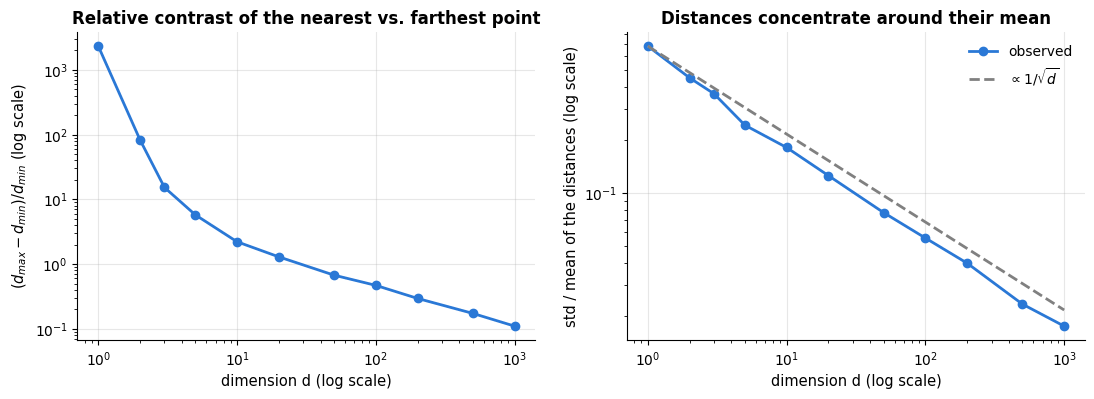

d =     2: the farthest of 1000 uniform points lies 83.90× the distance of the nearest
d =    10: the farthest of 1000 uniform points lies  3.21× the distance of the nearest
d =   100: the farthest of 1000 uniform points lies  1.47× the distance of the nearest
d =  1000: the farthest of 1000 uniform points lies  1.11× the distance of the nearest


In [11]:
dims = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000]
contrast, cv_dist = [], []
for d in dims:
    P = rng.uniform(size=(1000, d))                       # 1000 random points in the unit cube
    q = rng.uniform(size=(1, d))                          # one random query point
    dist = np.linalg.norm(P - q, axis=1)                  # (1000, d) - (1, d) broadcasts: 1000 distances
    contrast.append((dist.max() - dist.min()) / dist.min())
    cv_dist.append(dist.std() / dist.mean())              # coefficient of variation (not cross-validation)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(dims, contrast, marker="o")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("dimension d (log scale)"); axes[0].set_ylabel("$(d_{max} - d_{min}) / d_{min}$ (log scale)")
axes[0].set_title("Relative contrast of the nearest vs. farthest point")
axes[1].plot(dims, cv_dist, marker="o", label="observed")
# a reference curve proportional to 1/sqrt(d), starting from the observed value at d = 1
axes[1].plot(dims, cv_dist[0] / np.sqrt(np.array(dims)), ls="--", color="gray", label="$\\propto 1/\\sqrt{d}$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("dimension d (log scale)"); axes[1].set_ylabel("std / mean of the distances (log scale)")
axes[1].set_title("Distances concentrate around their mean")
axes[1].legend()
plt.show()
for d, c in zip(dims, contrast):
    if d in (2, 10, 100, 1000):
        # d_max / d_min = 1 + contrast
        print(f"d = {d:5d}: the farthest of 1000 uniform points lies {1 + c:5.2f}× the distance of the nearest")

### 3.3 Sample complexity: "local" is not local any more

Suppose we want a neighbourhood that captures a fraction $r$ of uniformly distributed data
in the unit cube — say the 1 % nearest points. A cube with that much volume has edge
length $e_d(r) = r^{1/d}$ (Hastie et al., 2009, §2.5). For $d = 10$ and $r = 0.01$,
$e_{10}(0.01) = 0.01^{0.1} \approx 0.63$: to find the nearest 1 % of the data you must
cover 63 % of the range of *every* coordinate. Such a neighbourhood is not "local" in any
meaningful sense — and averaging over it introduces exactly the bias that $k$NN was
supposed to avoid. Turning the statement around: to keep neighbourhoods as local as they
are with $n = 100$ points in one dimension, you need $100^d$ points in $d$ dimensions.
Data requirements grow *exponentially* with the dimension.

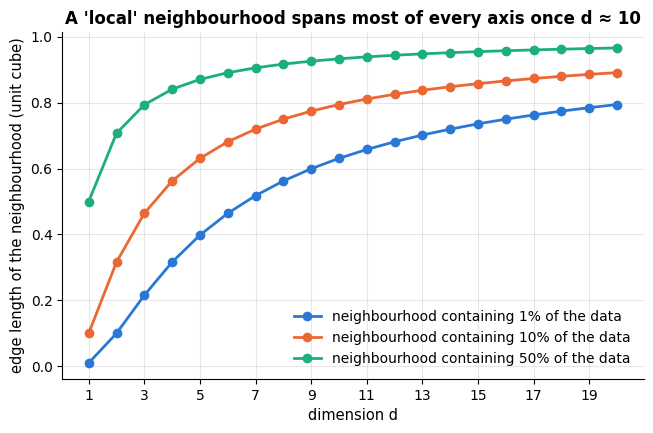

In [12]:
d_range = np.arange(1, 21)                        # dimensions 1, 2, ..., 20
fig, ax = plt.subplots()
for r in [0.01, 0.1, 0.5]:
    # edge length r^(1/d) of a cube holding a fraction r of the volume; {r:.0%} prints 0.01 as 1%
    ax.plot(d_range, r ** (1 / d_range), marker="o", label=f"neighbourhood containing {r:.0%} of the data")
ax.set_xlabel("dimension d")
ax.set_ylabel("edge length of the neighbourhood (unit cube)")
ax.set_title("A 'local' neighbourhood spans most of every axis once d ≈ 10")
ax.set_xticks(d_range[::2])                       # [::2]: every second dimension gets a tick
ax.legend()
plt.show()

### 3.4 What it does to $k$NN

The three facts combine into a practical rule: **local methods need $n$ to grow
exponentially with $d$**, and irrelevant features are not merely useless but actively
harmful, because they add noise to every distance. We demonstrate by appending pure-noise
features to the two-moons data. Logistic regression, which only has to learn that the
noise features carry zero weight, degrades gracefully; $k$NN degrades fast.

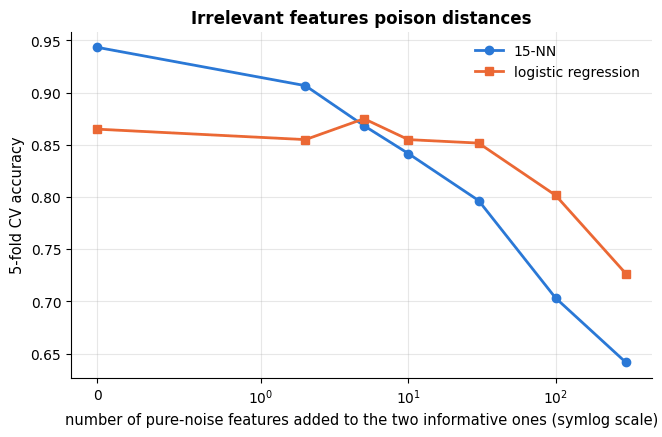

  0 noise features:  kNN 0.943   logistic regression 0.865
  2 noise features:  kNN 0.907   logistic regression 0.855
  5 noise features:  kNN 0.868   logistic regression 0.875
 10 noise features:  kNN 0.842   logistic regression 0.855
 30 noise features:  kNN 0.797   logistic regression 0.852
100 noise features:  kNN 0.703   logistic regression 0.802
300 noise features:  kNN 0.642   logistic regression 0.727


In [13]:
from sklearn.linear_model import LogisticRegression

X_base, y_base = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_STATE)
n_noise = [0, 2, 5, 10, 30, 100, 300]            # numbers of pure-noise features to append
acc_knn, acc_lr = [], []
for m in n_noise:
    X_aug = np.hstack([X_base, rng.normal(size=(len(X_base), m))])    # the 2 real features plus m noise columns
    # KNeighborsClassifier(15): the first positional argument is n_neighbors
    acc_knn.append(cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(15)), X_aug, y_base, cv=cv).mean())
    acc_lr.append(cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), X_aug, y_base, cv=cv).mean())

fig, ax = plt.subplots()
ax.plot(n_noise, acc_knn, marker="o", label="15-NN")
ax.plot(n_noise, acc_lr, marker="s", label="logistic regression")
ax.set_xscale("symlog", linthresh=1)             # "symlog": linear between -1 and 1, logarithmic beyond, so 0 fits
ax.set_xlabel("number of pure-noise features added to the two informative ones (symlog scale)")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Irrelevant features poison distances")
ax.legend()
plt.show()
for m, a, b in zip(n_noise, acc_knn, acc_lr):
    print(f"{m:3d} noise features:  kNN {a:.3f}   logistic regression {b:.3f}")

> **The blessing of structure.** If the curse were the whole story, nothing would work
> with images ($d = 10^6$ pixels) or text. It does work because real data do not fill
> $\mathbb{R}^d$ uniformly: they concentrate near low-dimensional **manifolds** (a face
> image has a few dozen degrees of freedom — pose, lighting, identity — not a million), and
> many features are redundant or irrelevant. The *intrinsic* dimension is what matters for
> $k$NN. This is the motivation for feature selection (notebook 4), dimensionality
> reduction (notebook 14) and representation learning, all of which can
> be read as attempts to find a space in which distances are meaningful again.

## 4. Naive Bayes

### 4.1 Bayes' theorem as a classifier

$k$NN never asks *how* the data were generated. A **generative** classifier does: it
models the class prior $P(y = c)$ and the class-conditional distribution of the features
$P(\mathbf{x} \mid y = c)$, and inverts them with Bayes' theorem (notebook 2),

$$
P(y = c \mid \mathbf{x}) \;=\; \frac{P(\mathbf{x} \mid y = c)\, P(y = c)}{P(\mathbf{x})}
\;\propto\; P(\mathbf{x} \mid y = c)\, P(y = c),
$$

predicting $\hat{y} = \arg\max_c P(\mathbf{x} \mid y = c) P(y = c)$ (the denominator is
the same for every class and can be dropped). The difficulty is $P(\mathbf{x} \mid y = c)$:
a joint distribution over $d$ features. With $d$ binary features it has $2^d - 1$ free
parameters per class, which no dataset can estimate. Naive Bayes cuts the knot with the
**naive independence assumption** — *given the class*, the features are independent:

$$
P(\mathbf{x} \mid y = c) \;=\; \prod_{j=1}^d P(x_j \mid y = c).
$$

Now each class needs only $d$ one-dimensional distributions, each estimated from the
training points of that class. The assumption is almost always false (words in a sentence
are not independent; the radius and area of a tumour are not independent) — and the method
works well anyway, for reasons we return to in section 4.5. Multiplying hundreds of small
probabilities underflows, so everything is done in log space:

$$
\log P(y = c \mid \mathbf{x}) \;=\; \log \pi_c + \sum_{j=1}^d \log P(x_j \mid y = c) + \text{const},
\qquad \pi_c = P(y = c).
$$

Which one-dimensional distribution to use depends on the type of the feature, and gives
the method its variants: **Gaussian** NB for continuous features, **multinomial** NB for
counts, **Bernoulli** NB for binary indicators (and `CategoricalNB` for nominal features).

### 4.2 Gaussian naive Bayes, derived and implemented

For continuous features assume $x_j \mid y = c \sim \mathcal{N}(\mu_{cj}, \sigma^2_{cj})$.
The maximum-likelihood estimates (notebook 2 derived them for a single Gaussian) are the
per-class sample mean and variance, and the prior is the class frequency:

$$
\hat{\mu}_{cj} = \frac{1}{n_c} \sum_{i: y_i = c} x_{ij}, \qquad
\hat{\sigma}^2_{cj} = \frac{1}{n_c} \sum_{i: y_i = c} (x_{ij} - \hat{\mu}_{cj})^2, \qquad
\hat{\pi}_c = \frac{n_c}{n}.
$$

The joint log-likelihood of a query is then

$$
\log P(y = c, \mathbf{x}) = \log \hat{\pi}_c - \frac{1}{2} \sum_{j=1}^d \left[ \log\big(2\pi \hat{\sigma}^2_{cj}\big) + \frac{(x_j - \hat{\mu}_{cj})^2}{\hat{\sigma}^2_{cj}} \right],
$$

and the posterior follows by normalising across classes (subtracting the row maximum
before exponentiating avoids overflow — the log-sum-exp trick). Training is a single pass
over the data: $O(nd)$, with $O(Kd)$ parameters. One numerical detail: a feature that is
constant within a class has $\hat\sigma^2 = 0$ and would divide by zero; scikit-learn adds
`var_smoothing` $\times$ (largest feature variance) to every variance, and we do the same
so that the two implementations agree exactly.

In [14]:
class GaussianNBScratch:
    """Gaussian naive Bayes with the same variance smoothing as scikit-learn's GaussianNB."""

    def __init__(self, var_smoothing=1e-9):
        """var_smoothing: fraction of the largest feature variance added to every variance."""
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        """Estimate per-class means, variances and log priors from X (n, d) and labels y; returns self."""
        X, y = np.asarray(X, dtype=float), np.asarray(y)
        self.classes_ = np.unique(y)
        # X[y == c] keeps the rows of class c; the list comprehension builds one row of statistics per class
        self.theta_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])   # per-class means, (K, d)
        self.var_ = np.array([X[y == c].var(axis=0) for c in self.classes_])      # per-class variances, (K, d)
        self.var_ += self.var_smoothing * X.var(axis=0).max()                     # numerical stability
        # np.mean(y == c) is the fraction of rows in class c, i.e. the prior estimate n_c / n
        self.class_log_prior_ = np.log(np.array([np.mean(y == c) for c in self.classes_]))
        return self

    def joint_log_likelihood(self, X):
        """log P(y = c) + log P(x | y = c) for every row of X and every class: an (n, K) array."""
        X = np.asarray(X, dtype=float)
        jll = np.empty((len(X), len(self.classes_)))
        for c in range(len(self.classes_)):
            # the sum over features of the log Gaussian density (independence turns the product into a sum)
            log_lik = -0.5 * np.sum(np.log(2 * np.pi * self.var_[c]) + (X - self.theta_[c]) ** 2 / self.var_[c], axis=1)
            jll[:, c] = self.class_log_prior_[c] + log_lik
        return jll

    def predict_proba(self, X):
        """Posterior class probabilities, (n, K): the joint log-likelihoods normalised across classes."""
        jll = self.joint_log_likelihood(X)
        jll -= jll.max(axis=1, keepdims=True)          # log-sum-exp trick
        p = np.exp(jll)
        return p / p.sum(axis=1, keepdims=True)

    def predict(self, X):
        """The class with the largest joint log-likelihood (the denominator P(x) does not change the argmax)."""
        return self.classes_[np.argmax(self.joint_log_likelihood(X), axis=1)]


from sklearn.naive_bayes import GaussianNB

# .to_numpy() turns the DataFrame / Series into plain arrays, as our class expects
Xw_train, Xw_test, yw_train, yw_test = train_test_split(X_wine.to_numpy(), y_wine.to_numpy(), test_size=0.3,
                                                        stratify=y_wine, random_state=RANDOM_STATE)
ours = GaussianNBScratch().fit(Xw_train, yw_train)
theirs = GaussianNB().fit(Xw_train, yw_train)
# scikit-learn names its fitted means theta_ and its variances var_, like our class
print(f"max |Δ means|      = {np.abs(ours.theta_ - theirs.theta_).max():.1e}")
print(f"max |Δ variances|  = {np.abs(ours.var_ - theirs.var_).max():.1e}")
print(f"max |Δ posterior|  = {np.abs(ours.predict_proba(Xw_test) - theirs.predict_proba(Xw_test)).max():.1e}")
print(f"test accuracy: ours {np.mean(ours.predict(Xw_test) == yw_test):.3f}, scikit-learn {theirs.score(Xw_test, yw_test):.3f}")

max |Δ means|      = 0.0e+00
max |Δ variances|  = 0.0e+00
max |Δ posterior|  = 2.7e-15
test accuracy: ours 1.000, scikit-learn 1.000


Note that Gaussian NB needs no feature scaling — each feature has its own variance —
and it fits in a single pass, which makes it a good "first model" on any numeric dataset.
Its decision boundaries are **quadratic** (the difference of two Gaussian log-densities
with different variances is a quadratic function of $\mathbf{x}$); if one forced all
classes to share the same variances, the boundaries would become linear and the method
would turn into a diagonal version of linear discriminant analysis (notebook 14).

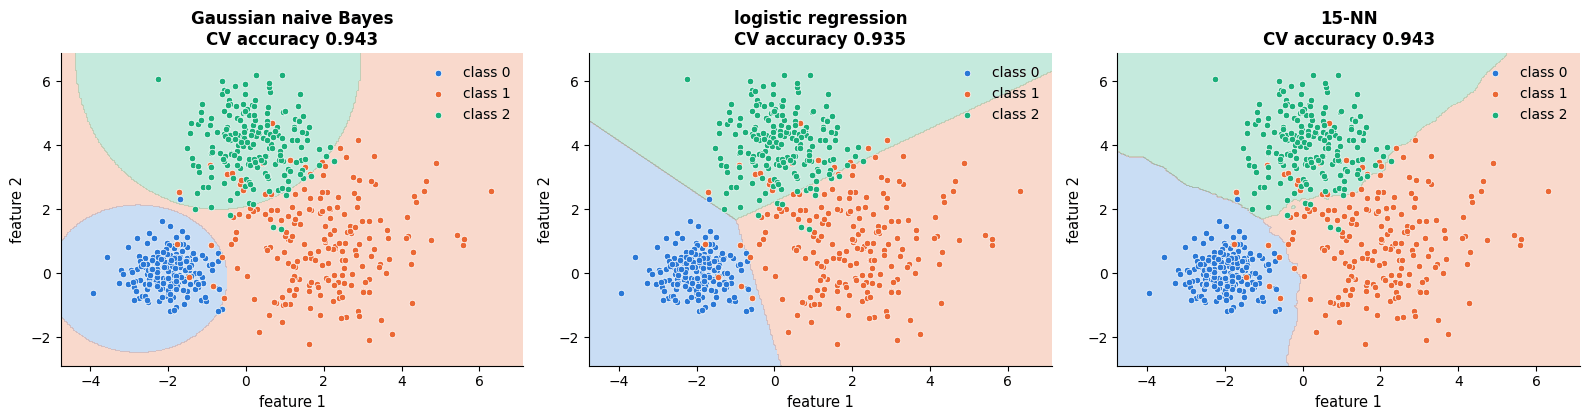

In [15]:
from sklearn.datasets import make_blobs          # Gaussian clusters ("blobs") around given centres

# three blobs with different spreads: cluster_std gives one standard deviation per blob
X_blob, y_blob = make_blobs(n_samples=600, centers=[[-2, 0], [2, 1], [0, 4]], cluster_std=[0.6, 1.4, 0.9],
                            random_state=RANDOM_STATE)
models = {"Gaussian naive Bayes": GaussianNB(),
          "logistic regression": LogisticRegression(max_iter=1000),
          "15-NN": KNeighborsClassifier(15)}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, (name, model) in zip(axes, models.items()):
    acc = cross_val_score(model, X_blob, y_blob, cv=cv).mean()
    # .fit returns the fitted model itself, so it can be passed straight to the plotting helper
    plot_decision_boundary(model.fit(X_blob, y_blob), X_blob, y_blob, ax=ax, title=f"{name}\nCV accuracy {acc:.3f}")
plt.tight_layout()
plt.show()

### 4.3 Multinomial and Bernoulli naive Bayes for text

Naive Bayes is *the* classic text classifier. Represent a document as a **bag of words**
(notebook 4; details in notebook 15): $x_j$ is the number of times word $j$ of a
vocabulary of size $V$ occurs. The **multinomial** model says that, given the class, a
document is generated by drawing its words independently from a class-specific
distribution $\boldsymbol{\theta}_c = (\theta_{c1}, \dots, \theta_{cV})$:

$$
P(\mathbf{x} \mid y = c) \;\propto\; \prod_{j=1}^V \theta_{cj}^{x_j},
\qquad
\hat{\theta}_{cj} = \frac{N_{cj} + \alpha}{N_c + \alpha V},
$$

where $N_{cj}$ is the total count of word $j$ in the documents of class $c$ and
$N_c = \sum_j N_{cj}$. The maximum-likelihood estimate is $\alpha = 0$, but a word that
never appears in the training documents of one class would then get $\theta_{cj} = 0$ and
veto that class for every document containing it. **Laplace (additive) smoothing** with
$\alpha = 1$ — pretend every word was seen once more per class — fixes this; smaller
$\alpha$ (Lidstone smoothing) is tuned by cross-validation. The **Bernoulli** model
instead uses presence/absence indicators and, crucially, also penalises a class for the
words that are *absent* from the document; McCallum & Nigam (1998) found the multinomial
model better for longer documents and larger vocabularies. We compare both, plus logistic
regression on the same counts, on the review corpus bundled with the course (2 400 short
product reviews labelled positive/negative — a synthetic corpus; online, notebook 15 also
uses the 20 Newsgroups data).

In [16]:
# CountVectorizer turns texts into a sparse document x word matrix of counts (a bag of words)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

reviews = load_reviews()                          # a DataFrame with (among others) the columns text and sentiment
# .to_string(index=False, max_colwidth=90) prints the rows as plain text, cutting long texts at 90 characters
print(reviews[["text", "sentiment"]].head(3).to_string(index=False, max_colwidth=90))
text_train, text_test, s_train, s_test = train_test_split(reviews["text"], reviews["sentiment"], test_size=0.25,
                                                          stratify=reviews["sentiment"], random_state=RANDOM_STATE)
vectorizer = CountVectorizer()                     # tokenise, lower-case, count; fitted on the training texts only
C_train = vectorizer.fit_transform(text_train)     # learn the vocabulary and count: a sparse (documents, words) matrix
C_test = vectorizer.transform(text_test)           # count with the training vocabulary; unseen words are ignored
vocab = vectorizer.get_feature_names_out()         # the vocabulary, in column order
# .nnz is the number of non-zero entries a sparse matrix stores; np.prod(shape) is the number of cells
print(f"\n{C_train.shape[0]} training documents, vocabulary of {len(vocab)} words, "
      f"{100 * C_train.nnz / np.prod(C_train.shape):.1f}% of the count matrix is non-zero")

# alpha is the additive (Laplace) smoothing; BernoulliNB turns every count above 0 into 1 (word present)
for name, model in [("multinomial NB (α = 1)", MultinomialNB(alpha=1.0)),
                    ("Bernoulli NB (α = 1)", BernoulliNB(alpha=1.0)),
                    ("logistic regression", LogisticRegression(max_iter=2000))]:
    model.fit(C_train, s_train)
    print(f"{name:25s} test accuracy {model.score(C_test, s_test):.3f}")

                                                                                      text  sentiment
I was skeptical but the sound turned out lovely. Five stars for the fantastic sound. Pr...          1
Not comfortable at all — the fit is dreadful. Nothing about the bass is impressive; it ...          0
                                 Manual is in three languages. Honestly poor noise, avoid.          0

1800 training documents, vocabulary of 133 words, 10.3% of the count matrix is non-zero
multinomial NB (α = 1)    test accuracy 0.972
Bernoulli NB (α = 1)      test accuracy 0.972
logistic regression       test accuracy 0.967


The fitted parameters of a naive Bayes text model are directly interpretable: the words
with the largest log-ratio $\log(\theta_{1j} / \theta_{0j})$ are the strongest indicators
of positive sentiment.

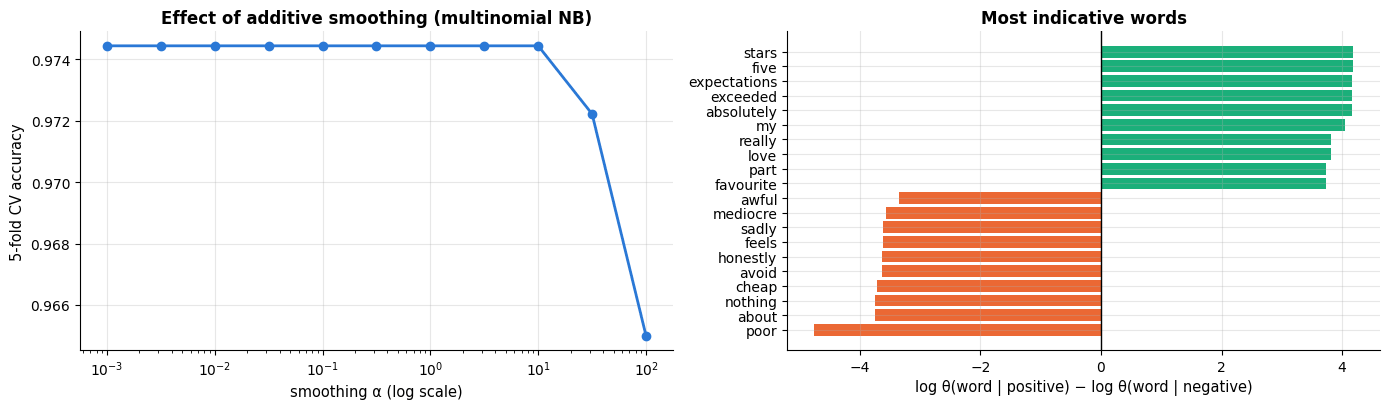

In [17]:
alphas = np.logspace(-3, 2, 11)                  # 11 values from 10^-3 to 10^2, evenly spaced on a log scale
acc_alpha = [cross_val_score(MultinomialNB(alpha=a), C_train, s_train, cv=cv).mean() for a in alphas]
mnb = MultinomialNB(alpha=1.0).fit(C_train, s_train)
# feature_log_prob_ is a (classes, words) array of log θ_cj; row 1 minus row 0 is log(θ_1j / θ_0j)
log_ratio = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]
order = np.argsort(log_ratio)                    # word positions from most negative to most positive log-ratio

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(alphas, acc_alpha, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("smoothing α (log scale)")
axes[0].set_ylabel("5-fold CV accuracy")
axes[0].set_title("Effect of additive smoothing (multinomial NB)")
top = np.r_[order[:10], order[-10:]]             # np.r_[...] concatenates: the 10 most negative and 10 most positive
# orange bars for negative-sentiment words, green for positive ones
axes[1].barh(vocab[top], log_ratio[top], color=[PALETTE[1] if v < 0 else PALETTE[2] for v in log_ratio[top]])
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("log θ(word | positive) − log θ(word | negative)")
axes[1].set_title("Most indicative words")
plt.tight_layout()
plt.show()

### 4.4 Naive Bayes is a linear classifier

Take the log-odds of the two classes under the multinomial model:

$$
\log \frac{P(y = 1 \mid \mathbf{x})}{P(y = 0 \mid \mathbf{x})}
\;=\; \underbrace{\log \frac{\pi_1}{\pi_0}}_{b} \;+\; \sum_{j=1}^V x_j \underbrace{\log \frac{\theta_{1j}}{\theta_{0j}}}_{w_j}
\;=\; \mathbf{w}^\top \mathbf{x} + b .
$$

The decision function is *linear* in the counts — exactly the form of logistic regression
(notebook 7), and the Gaussian model with shared variances or the Bernoulli model give the
same conclusion. The two methods share a hypothesis space and differ only in how the
weights are chosen: naive Bayes sets $w_j$ from per-class *counts* (a generative,
closed-form estimate), logistic regression sets $\mathbf{w}$ by minimising the
cross-entropy of the *conditional* model (a discriminative, iterative estimate). We verify
the identity numerically.

In [18]:
w_nb = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]     # the weights w_j = log(θ_1j / θ_0j)
b_nb = mnb.class_log_prior_[1] - mnb.class_log_prior_[0]       # the intercept b = log(π_1 / π_0)
linear_scores = C_test @ w_nb + b_nb                      # w^T x + b for every test document
log_post = mnb.predict_log_proba(C_test)                  # (documents, 2) array of log posterior probabilities
# the model's log-odds are column 1 minus column 0
print(f"max |(w^T x + b) − log-odds from predict_log_proba| = {np.abs(linear_scores - (log_post[:, 1] - log_post[:, 0])).max():.1e}")

max |(w^T x + b) − log-odds from predict_log_proba| = 7.1e-14


### 4.5 Why it works anyway — and why its probabilities do not

The independence assumption is false for almost every real dataset, yet naive Bayes is
often competitive on accuracy. Zhang (2004) gives the explanation: classification only
requires the *ranking* of the classes to be right, not the probabilities, and
dependencies between features often either cancel out or affect all classes similarly.
Domingos & Pazzani (1997) had already shown that NB is optimal for some strongly dependent
feature sets under 0–1 loss. What the violated assumption *does* destroy is
**calibration**: correlated features count as independent evidence, so the posterior is
pushed towards 0 or 1 far too confidently. The cleanest demonstration is to *duplicate
every feature*: the accuracy does not change at all, while every log-odds doubles.

accuracy: original features 0.947, duplicated features 0.942
median |log-odds|: original 30.6, duplicated 61.2  (ratio 2.00)
fraction of test predictions with confidence > 0.99: NB 0.95


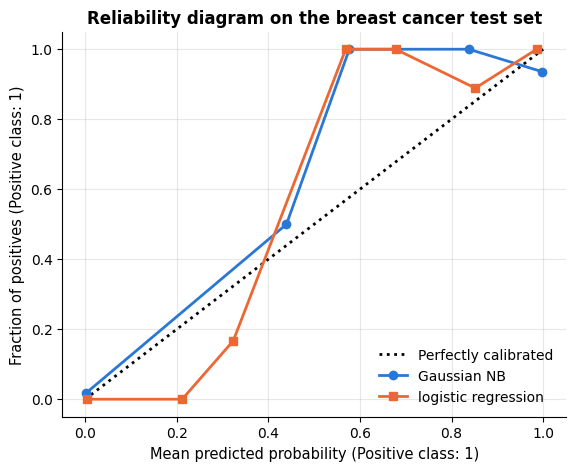

In [19]:
from sklearn.datasets import load_breast_cancer          # 569 biopsies, 30 features; target 0 = malignant, 1 = benign
# CalibrationDisplay draws a reliability diagram (observed frequency against mean predicted probability, per bin)
from sklearn.calibration import CalibrationDisplay

cancer = load_breast_cancer()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(cancer.data, cancer.target, test_size=0.3,
                                                        stratify=cancer.target, random_state=RANDOM_STATE)
gnb = GaussianNB().fit(Xc_train, yc_train)
gnb_dup = GaussianNB().fit(np.hstack([Xc_train, Xc_train]), yc_train)      # every feature twice
p1 = gnb.predict_proba(Xc_test)[:, 1]            # predict_proba returns (n, 2); column 1 is P(class 1)

def log_odds(model, X):
    """log P(y=1|x) - log P(y=0|x), read from the log-probabilities so that nothing is clipped.

    Returns one value per row of X (via predict_proba, extreme probabilities would round to exactly 0 or 1).
    """
    lp = model.predict_log_proba(X)
    return lp[:, 1] - lp[:, 0]

lo_single = log_odds(gnb, Xc_test)
lo_double = log_odds(gnb_dup, np.hstack([Xc_test, Xc_test]))
print(f"accuracy: original features {gnb.score(Xc_test, yc_test):.3f}, duplicated features {gnb_dup.score(np.hstack([Xc_test, Xc_test]), yc_test):.3f}")
print(f"median |log-odds|: original {np.median(np.abs(lo_single)):.1f}, duplicated {np.median(np.abs(lo_double)):.1f}  "
      f"(ratio {np.median(np.abs(lo_double)) / np.median(np.abs(lo_single)):.2f})")
# np.maximum(p1, 1 - p1) is the probability of the predicted class, i.e. the model's confidence
print(f"fraction of test predictions with confidence > 0.99: NB {np.mean(np.maximum(p1, 1 - p1) > 0.99):.2f}")

lr_cal = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xc_train, yc_train)
fig, ax = plt.subplots(figsize=(6.5, 5))
# from_estimator computes the model's P(class 1) on the test data, bins it into n_bins equal-width bins and plots
CalibrationDisplay.from_estimator(gnb, Xc_test, yc_test, n_bins=8, name="Gaussian NB", ax=ax, marker="o")
CalibrationDisplay.from_estimator(lr_cal, Xc_test, yc_test, n_bins=8, name="logistic regression", ax=ax, marker="s")
ax.set_title("Reliability diagram on the breast cancer test set")
plt.show()

The reliability diagram (notebook 7) shows the typical naive Bayes signature: almost all
predictions are pushed to the extreme bins, and some of the confident bins are less
accurate than they claim. If you need probabilities from naive Bayes — for thresholding,
ranking, or expected-cost decisions — wrap it in `CalibratedClassifierCV` (notebook 7).

## 5. Generative vs. discriminative models

Naive Bayes and logistic regression form a **generative–discriminative pair**: the same
linear decision function, estimated two ways. Which estimate is better? Ng & Jordan (2002)
analysed exactly this pair and reached a two-part conclusion:

1. The discriminative model has the **lower asymptotic error**: with unlimited data,
   logistic regression is at least as good, because it makes fewer assumptions (it does
   not care whether the features are conditionally independent).
2. The generative model **converges to its asymptote much faster**: naive Bayes needs on
   the order of $\log d$ training examples to get close to its best error, logistic
   regression on the order of $d$. Each NB parameter is estimated from a simple
   per-feature count, whereas the discriminative weights are coupled through the loss.

So there may be *two regimes*: with little data naive Bayes can win; with a lot of data
logistic regression wins. Let us look at learning curves (notebook 5) on two datasets: a
synthetic one where the NB assumption holds exactly (50 conditionally independent Gaussian
features), and the 8 × 8 handwritten digits, where it is badly violated (neighbouring
pixels are strongly correlated).

synthetic Gaussian naive Bayes   n =   12 → 0.543;  n =  240 → 0.808;  n = 2400 → 0.847
synthetic logistic regression    n =   12 → 0.623;  n =  240 → 0.795;  n = 2400 → 0.838
digits: a Gaussian naive Bayes   n =   28 → 0.391;  n =  287 → 0.809;  n = 1437 → 0.845
digits: a logistic regression    n =   28 → 0.680;  n =  287 → 0.934;  n = 1437 → 0.971


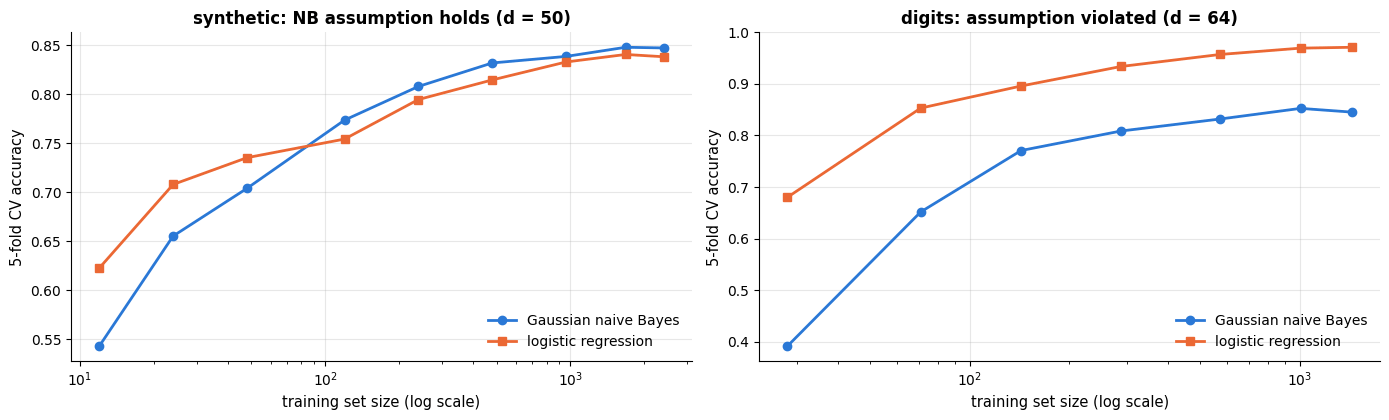

In [20]:
from sklearn.datasets import load_digits                 # 1797 handwritten digits, 8 x 8 images = 64 pixel features
# learning_curve fits a model on growing subsets of each training fold and scores it on the validation fold
from sklearn.model_selection import learning_curve

d_syn = 50
y_syn = rng.integers(0, 2, 3000)
shift = rng.normal(0, 0.35, d_syn)                       # per-feature difference between the class means
# (3000, 1) * (1, 50) -> (3000, 50): class-1 rows get the shift, class-0 rows get zeros
X_syn = rng.normal(size=(3000, d_syn)) + y_syn[:, None] * shift[None, :]
digits = load_digits()

# title -> (X, y, training-set sizes as fractions of the largest possible training set)
datasets = {"synthetic: NB assumption holds (d = 50)": (X_syn, y_syn, np.array([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0])),
            "digits: assumption violated (d = 64)": (digits.data, digits.target, np.array([0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0]))}
learners = {"Gaussian naive Bayes": GaussianNB(),
            "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, (title, (Xd, yd, sizes)) in zip(axes, datasets.items()):
    for (name, model), marker in zip(learners.items(), ["o", "s"]):
        # returns the absolute training sizes used, the training scores (discarded with _) and the validation
        # scores, both of shape (number of sizes, 5 folds); shuffle=True shuffles before taking each subset
        n_used, _, test_scores = learning_curve(model, Xd, yd, train_sizes=sizes, cv=cv, shuffle=True,
                                                random_state=RANDOM_STATE)
        ax.plot(n_used, test_scores.mean(axis=1), marker=marker, label=name)
        # title[:9] keeps the first 9 characters; the three columns are the first, middle and last training size
        print(f"{title[:9]:9s} {name:22s} n = {n_used[0]:4d} → {test_scores.mean(axis=1)[0]:.3f};  "
              f"n = {n_used[len(n_used) // 2]:4d} → {test_scores.mean(axis=1)[len(n_used) // 2]:.3f};  "
              f"n = {n_used[-1]:4d} → {test_scores.mean(axis=1)[-1]:.3f}")
    ax.set_xscale("log")
    ax.set_xlabel("training set size (log scale)")
    ax.set_ylabel("5-fold CV accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Read the curves against the two claims. Naive Bayes flattens out early on both datasets —
it reaches its asymptote with a few hundred examples, as claim 2 predicts. On the
synthetic data, where its assumptions hold, it is ahead of logistic regression in the
middle of the curve and the two meet at the end (the Bayes error of this problem is about
0.11). On the digits, whose pixels are far from conditionally independent, logistic
regression is better at every size and its advantage *grows* with $n$: the generative
model's bias never goes away, exactly as claim 1 says. Note one modern nuance: Ng & Jordan
used unregularised logistic regression; the L2-regularised version we use here has its own
inductive bias that makes it robust with tiny samples, which is why NB does not win at the
very smallest sizes even on the synthetic data.

> **Key idea.** Generative models turn assumptions into data efficiency: if the
> assumptions are right you need less data, if they are wrong you pay with a permanent
> bias. Discriminative models assume less and therefore need more data, but end up better.
> This trade-off reappears in notebook 13 (Gaussian mixtures), and again in the generative
> models of a dedicated deep-learning course.

## 6. Neighbours as density estimators: Parzen windows and anomaly scores

There is a second way to read $k$NN. The Bayes classifier of section 4 needs the
class-conditional densities $p(\mathbf{x} \mid y = c)$; naive Bayes assumed a parametric
form for them. A **non-parametric** alternative estimates a density directly from the
sample. Two classic estimators (Bishop, 2006, §2.5):

- **Kernel density estimation** (KDE, the *Parzen window*; Parzen, 1962): place a bump of
  width $h$ on every training point and add them up,
  $$\hat{p}(\mathbf{x}) = \frac{1}{n} \sum_{i=1}^n \frac{1}{h^d} K\!\left(\frac{\mathbf{x} - \mathbf{x}_i}{h}\right),$$
  with a kernel $K$ (Gaussian, top-hat, …) that integrates to one. The bandwidth $h$ plays
  the role of $k$: fix the *volume*, count the points.
- **$k$NN density estimation**: fix the *number of points*, measure the volume.
  $\hat{p}(\mathbf{x}) = \dfrac{k}{n\, V_k(\mathbf{x})}$, where $V_k(\mathbf{x})$ is the
  volume of the smallest ball around $\mathbf{x}$ that contains $k$ training points.

Plugging $k$NN density estimates of each class into Bayes' theorem gives back the $k$NN
classification rule — the two halves of this notebook are the same idea. In one dimension
we can watch the bandwidth trade-off directly.

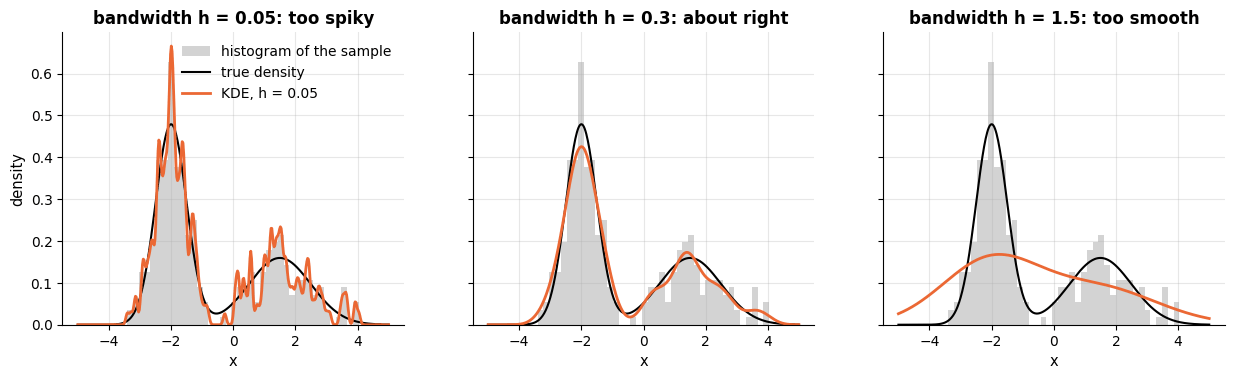

In [21]:
from sklearn.neighbors import KernelDensity      # kernel density estimation

# a bimodal ground truth: 60 % N(-2, 0.5²) + 40 % N(1.5, 1²)
n_kde = 300
component = rng.random(n_kde) < 0.6              # True (first component) with probability 0.6
# np.where(cond, a, b) takes a where cond is True and b elsewhere: one draw from the chosen component per point
x_kde = np.where(component, rng.normal(-2, 0.5, n_kde), rng.normal(1.5, 1.0, n_kde))
grid = np.linspace(-5, 5, 400)
true_density = 0.6 * norm.pdf(grid, -2, 0.5) + 0.4 * norm.pdf(grid, 1.5, 1.0)   # norm.pdf(x, mean, std)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, h in zip(axes, [0.05, 0.3, 1.5]):
    kde = KernelDensity(kernel="gaussian", bandwidth=h).fit(x_kde[:, None])     # a Gaussian bump of width h per point
    ax.hist(x_kde, bins=40, density=True, color="lightgray", label="histogram of the sample")   # density=True: area 1
    ax.plot(grid, true_density, color="black", lw=1.5, label="true density")
    # score_samples returns the log of the estimated density, hence np.exp
    ax.plot(grid, np.exp(kde.score_samples(grid[:, None])), color=PALETTE[1], lw=2, label=f"KDE, h = {h}")
    ax.set_title(f"bandwidth h = {h}: " + ("too spiky" if h == 0.05 else "too smooth" if h == 1.5 else "about right"))
    ax.set_xlabel("x")
axes[0].set_ylabel("density")
axes[0].legend()
plt.show()

The same machinery gives a first **anomaly detector**: a point whose $k$-th nearest
neighbour is far away sits in a low-density region. The distance to the $k$-th neighbour
(or the mean distance to the $k$ nearest) is a perfectly serviceable anomaly score, and the
starting point for the local outlier factor of notebook 13.

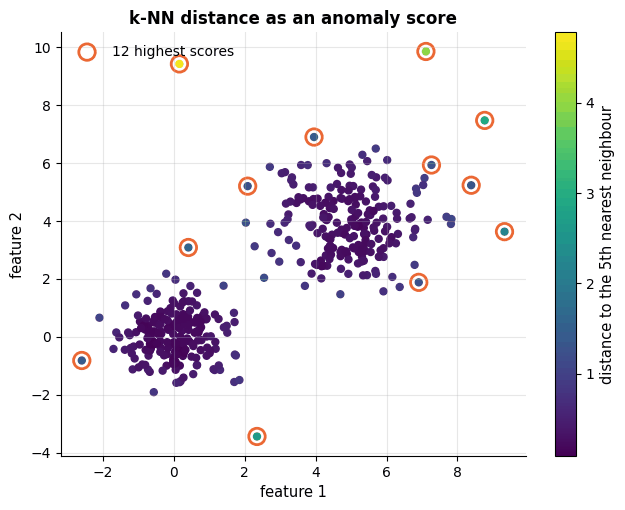

6 of the 12 flagged points are true anomalies (of 12 injected)


In [22]:
from sklearn.neighbors import NearestNeighbors   # neighbour search only, without any prediction

# X_in, _ = ...: keep the points and discard the blob labels
X_in, _ = make_blobs(n_samples=400, centers=[[0, 0], [5, 4]], cluster_std=[0.8, 1.1], random_state=RANDOM_STATE)
X_out = rng.uniform(-4, 10, size=(12, 2))                     # a dozen scattered anomalies
X_all = np.vstack([X_in, X_out])                              # stack the rows: (412, 2)
# np.r_ joins the two arrays: False for the 400 normal points, True for the 12 injected anomalies
is_outlier = np.r_[np.zeros(len(X_in), bool), np.ones(len(X_out), bool)]

nn = NearestNeighbors(n_neighbors=6).fit(X_all)                  # 6 because a point is its own nearest neighbour
dist, _ = nn.kneighbors(X_all)              # (412, 6) distances to the 6 nearest points, in increasing order
score = dist[:, -1]                                               # distance to the 5th other point
flagged = np.argsort(score)[-12:]                                 # the 12 highest scores

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sc = ax.scatter(X_all[:, 0], X_all[:, 1], c=score, cmap="viridis", s=25)      # c=score colours each point by its score
# facecolor="none" draws hollow rings around the flagged points
ax.scatter(X_all[flagged, 0], X_all[flagged, 1], facecolor="none", edgecolor=PALETTE[1], s=140, lw=2,
           label="12 highest scores")
plt.colorbar(sc, ax=ax, label="distance to the 5th nearest neighbour")
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
ax.set_title("k-NN distance as an anomaly score")
ax.legend(loc="upper left")
plt.show()
print(f"{is_outlier[flagged].sum()} of the 12 flagged points are true anomalies "      # True counts as 1 in a sum
      f"(of {is_outlier.sum()} injected)")

## 7. Strengths, weaknesses and when to use it

The two families in this notebook sit at opposite ends of almost every axis. $k$NN stores
everything and assumes almost nothing; naive Bayes stores almost nothing and assumes a great
deal. Knowing *which* assumption each one makes tells you in advance where it will fail —
and the three experiments after the tables make two of those failures visible.

### 7.1 The three methods at a glance

**$k$-nearest neighbours** (`KNeighborsClassifier`, `KNeighborsRegressor`)

| | |
|---|---|
| **Assumptions / inductive bias** | smoothness: points that are close in the chosen metric have similar targets. No assumption about the *shape* of the boundary — hence universal consistency (section 1.5) — but a very strong assumption that your distance is meaningful, i.e. that every feature deserves the weight its units give it. |
| **Strengths** | no training phase; one interpretable knob ($k$); fits arbitrarily irregular boundaries; naturally multi-class and multi-output; works for regression, classification, density estimation (section 6) and anomaly scoring with the same machinery; excellent for small $n$ with few, well-scaled features; the retrieved neighbours *are* the explanation ("these five similar patients"). |
| **Weaknesses / failure modes** | scale-sensitive to the point of uselessness on raw features (7.2); degrades fast with irrelevant features and with dimension (section 3.4); prediction is $O(nd)$ per query and the whole training set must stay in memory; no model to inspect or ship; struggles with class imbalance (the majority class dominates neighbourhoods); missing values must be imputed before any distance is computed. |
| **Data it suits** | $n$ up to ~$10^5$, $d$ small (say $\le 20$ after selection or PCA), numeric features on a common scale, balanced classes, no strict latency budget. |
| **Complexity** | training $O(1)$ (store the data), memory $O(nd)$; prediction $O(nd)$ per query by brute force, $O(d \log n)$ with a KD/ball tree in low $d$ (section 2). |
| **Interpretability** | local and case-based: you can show the neighbours that produced a prediction, but there is no global rule, no coefficient, no feature importance. |
| **Use it when / avoid it when** | Use it as a strong non-linear baseline on small, low-dimensional, scaled data, or when the neighbours themselves are the product (recommendation, retrieval). Avoid it with many features, huge $n$, tight latency, or when you must explain a global rule. |

**Gaussian naive Bayes** (`GaussianNB`)

| | |
|---|---|
| **Assumptions / inductive bias** | within each class, every feature is Gaussian *and* independent of the others; classes differ in per-feature means and variances. The decision boundary is quadratic and **axis-aligned** — it cannot use correlations (7.3). |
| **Strengths** | trains in a single pass, $O(nd)$, on data that need not fit in memory (`partial_fit`); only $2Kd + K$ parameters, so it works with tiny $n$ (section 5); no scaling needed; robust to irrelevant features (a feature with equal class means contributes nothing); handles many classes at no extra cost; a genuinely useful five-second baseline. |
| **Weaknesses / failure modes** | the independence assumption is almost always false — accuracy survives (Zhang, 2004) but **calibration does not** (section 4.5); it is blind to information carried by correlations (7.3); a feature that is far from Gaussian (bimodal, heavy-tailed, count-like) breaks the likelihood; zero variance within a class needs `var_smoothing`. |
| **Data it suits** | continuous features that are roughly unimodal per class, any $n$ (especially small), any $d$ including $d \gg n$; tolerant of irrelevant features. |
| **Complexity** | training $O(nd)$, one pass; prediction $O(Kd)$ per query; memory $O(Kd)$ — independent of $n$. |
| **Interpretability** | high: per-class means and variances per feature, and a log-odds contribution per feature that you can read off directly (section 4.4). |
| **Use it when / avoid it when** | Use it as the first baseline on numeric data, with very little data, or when you need per-feature evidence. Avoid it when features are strongly correlated and you need probabilities, or when the class-conditional shapes are clearly not Gaussian. |

**Multinomial naive Bayes** (`MultinomialNB`, and `BernoulliNB` for indicators)

| | |
|---|---|
| **Assumptions / inductive bias** | a document (or any count vector) is a bag of independent draws from a per-class word distribution; word order and co-occurrence carry no information. Smoothing $\alpha$ encodes a Dirichlet prior over the vocabulary. |
| **Strengths** | superb on sparse high-dimensional counts — the regime where $k$NN is helpless; trains in one pass over the non-zero entries; needs very little data per class; the log-ratios are a readable word list (section 4.3); the classic spam / topic baseline that is still hard to beat cheaply. |
| **Weaknesses / failure modes** | without smoothing a single unseen word vetoes a class ($\theta = 0$, section 4.3) — `alpha = 0` is a genuine failure mode, not a limit case; correlated word pairs ("New York") count twice, so posteriors are extreme; longer documents make the over-counting worse; requires non-negative features, so it cannot take arbitrary continuous inputs; ignores word order entirely (n-grams are a partial patch, notebook 15). |
| **Data it suits** | counts or TF–IDF weights, vocabularies of $10^3$–$10^6$, sparse matrices, any number of classes. |
| **Complexity** | training $O(\text{nnz})$ — the number of non-zero entries; prediction $O(\text{nnz per document} \times K)$; memory $O(KV)$. |
| **Interpretability** | the highest of the three: $\log(\theta_{1j}/\theta_{0j})$ per word *is* the model, and it is a linear score (section 4.4). |
| **Use it when / avoid it when** | Use it for text and count data as a baseline, for streaming updates, and when you need an explainable word list. Avoid it when you need calibrated probabilities, when feature interactions matter, or when a linear model on TF–IDF (notebook 15) is affordable — it is usually a little better. |

### 7.2 Failure mode 1: $k$NN believes your units

Section 1.2 measured the damage in numbers: 5-NN on the raw wine features scores 0.68,
on standardised features 0.97. Here is the same failure as a picture. We keep two of the
thirteen features — `proline` (hundreds to ~1700) and `hue` (roughly 0.5 to 1.7) — and draw
the decision regions on the raw features and on the standardised ones.

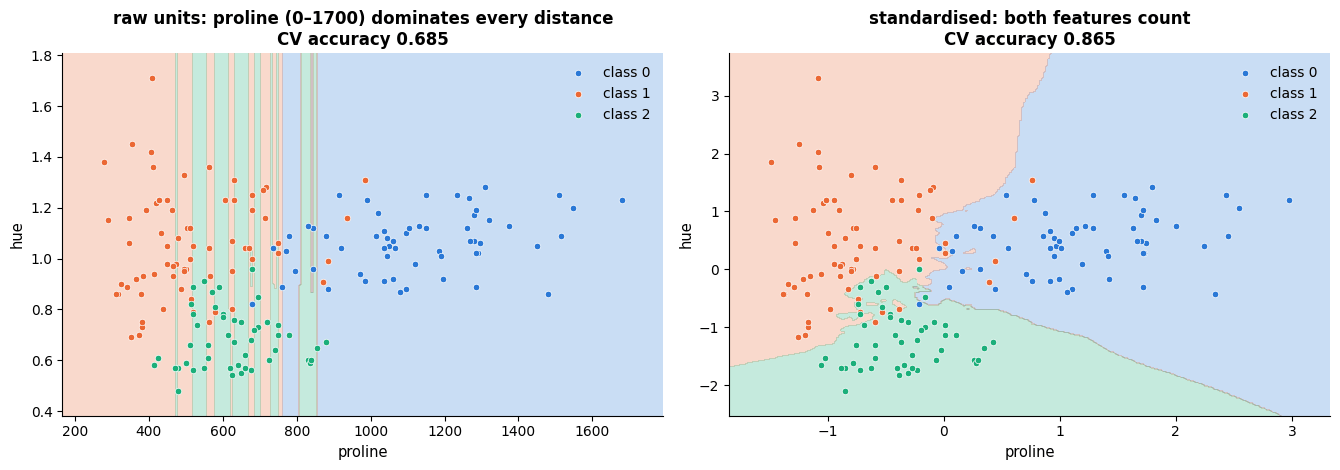

with all 13 features:  raw 0.680   standardised 0.972  (section 1.2)


In [23]:
wine2 = X_wine[["proline", "hue"]].to_numpy()          # two of the 13 wine features, as an (n, 2) array
wine2_scaled = StandardScaler().fit_transform(wine2)   # fit_transform: learn each column's mean and std, then scale

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, (X_v, title) in zip(axes, [(wine2, "raw units: proline (0–1700) dominates every distance"),
                                   (wine2_scaled, "standardised: both features count")]):
    clf = KNeighborsClassifier(n_neighbors=5).fit(X_v, y_wine)       # fitted on all the data, for the picture
    acc = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_v, y_wine, cv=cv).mean()
    plot_decision_boundary(clf, X_v, y_wine, ax=ax, title=f"{title}\nCV accuracy {acc:.3f}",
                           feature_names=("proline", "hue"))
plt.tight_layout()
plt.show()
print("with all 13 features:  raw 0.680   standardised 0.972  (section 1.2)")

On the left the regions are almost perfectly **vertical**: a difference of 0.3 in `hue` —
which separates the cultivars rather well — is invisible next to a difference of 300 in
`proline`, so the classifier effectively uses one feature. On the right the same algorithm
on the same data uses both. Nothing about the *model* changed; only the units did. This is
why every $k$NN in this course lives inside `make_pipeline(StandardScaler(), ...)`, and it
is worth remembering that the symptom — mediocre accuracy — never points at the cause.

> **Warning.** Scaling is not free of choices either. `StandardScaler` gives every feature
> equal weight, which is right only if every feature is equally relevant; `MinMaxScaler` is
> sensitive to outliers; domain weights (or a supervised metric, see `NeighborhoodComponentsAnalysis`)
> can beat both. "Scale, then tune $k$" is the default, not the optimum.

### 7.3 Failure mode 2: naive Bayes cannot see a correlation

Naive Bayes throws away the dependence between features *by construction*, so the cleanest
way to break it is to put all the information there. In the data below the two features are
standard normal *within every class* — identical marginals, identical means, identical
variances — and the classes differ only in the **sign of their correlation**: class 0 lies
along the diagonal, class 1 along the anti-diagonal.

class-conditional means and standard deviations (they are the same for both classes):
  class 0: mean (-0.03, -0.00)   sd (1.12, 1.22)   correlation +0.92
  class 1: mean (-0.11, +0.12)   sd (1.18, 1.26)   correlation -0.94


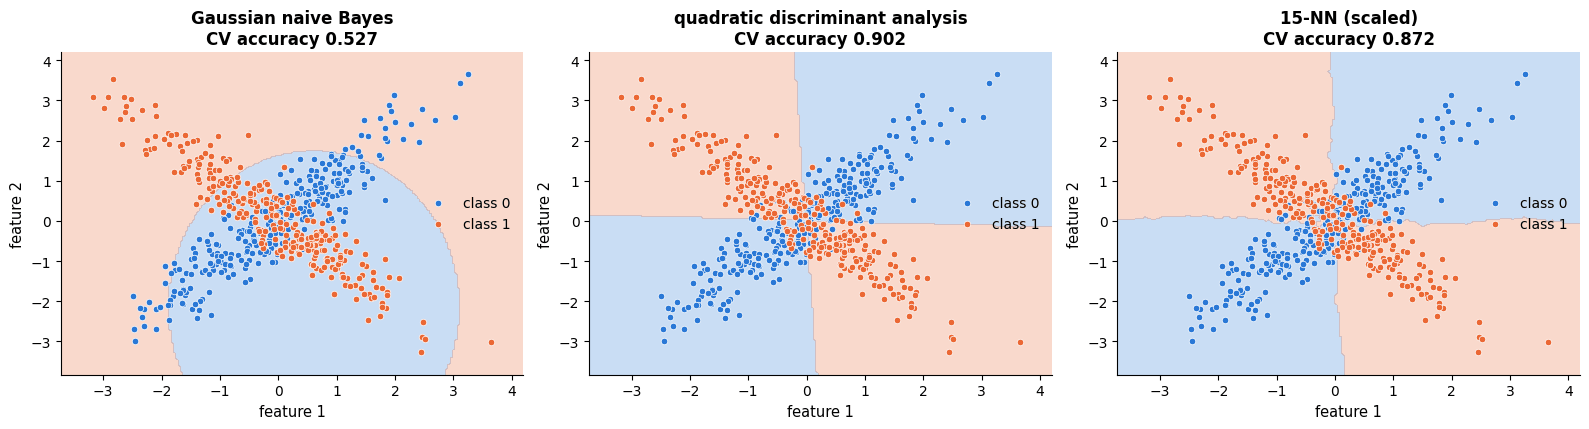

In [24]:
# QDA: one Gaussian with its own full covariance matrix per class, so it can use correlations
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

n_x = 600
y_x = rng.integers(0, 2, n_x)
t_x = rng.normal(0, 1.2, n_x)
# np.c_[a, b] puts the two arrays side by side as columns; the second feature is +t for class 0
# and -t for class 1 (plus noise), so only the sign of the correlation differs between the classes
X_x = np.c_[t_x, np.where(y_x == 1, -t_x, t_x) + rng.normal(0, 0.45, n_x)]

print("class-conditional means and standard deviations (they are the same for both classes):")
for c in (0, 1):
    m, s = X_x[y_x == c].mean(axis=0), X_x[y_x == c].std(axis=0)
    # :+.2f always prints the sign; np.corrcoef treats each row as one variable, hence the .T, and [0, 1] is
    # the correlation between the two features
    print(f"  class {c}: mean ({m[0]:+.2f}, {m[1]:+.2f})   sd ({s[0]:.2f}, {s[1]:.2f})   "
          f"correlation {np.corrcoef(X_x[y_x == c].T)[0, 1]:+.2f}")

x_models = {"Gaussian naive Bayes": GaussianNB(),
            "quadratic discriminant analysis": QuadraticDiscriminantAnalysis(),
            "15-NN (scaled)": make_pipeline(StandardScaler(), KNeighborsClassifier(15))}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, (name, model) in zip(axes, x_models.items()):
    acc = cross_val_score(model, X_x, y_x, cv=cv).mean()
    # resolution=200: evaluate the model on a 200 x 200 grid (the default is 300), which is faster
    plot_decision_boundary(model.fit(X_x, y_x), X_x, y_x, ax=ax, resolution=200,
                           title=f"{name}\nCV accuracy {acc:.3f}")
plt.tight_layout()
plt.show()

Gaussian naive Bayes is at chance (0.53). It is not badly tuned and it is not short of
data: the per-feature statistics it is allowed to look at — one mean and one variance per
feature per class — are identical in the two classes up to sampling noise, so the circular
boundary in the left panel is fitted to noise and nothing else. QDA, which estimates a full
covariance matrix per class, recovers the X (0.90; the two arms genuinely overlap near the
origin, so perfection is impossible), and $k$NN, which assumes nothing about shape at all,
is close behind (0.87).

Real data rarely conspire this hard, which is why naive Bayes survives in practice
(section 4.5). But the ingredient of this example — information that lives in the
*relationship* between features rather than in any feature alone — is extremely common:
ratios (BMI from height and weight), differences (pre- versus post-treatment), and
interactions of every kind. If you suspect one, either build the interaction as an explicit
feature (notebook 4) or use a model that can see it.

### 7.4 The price of laziness, measured

The third weakness is not statistical but operational, and it decides more deployments than
accuracy does: $k$NN moves all of its cost to prediction time, where it also grows with the
size of the training set. The generative and discriminative models do the opposite.

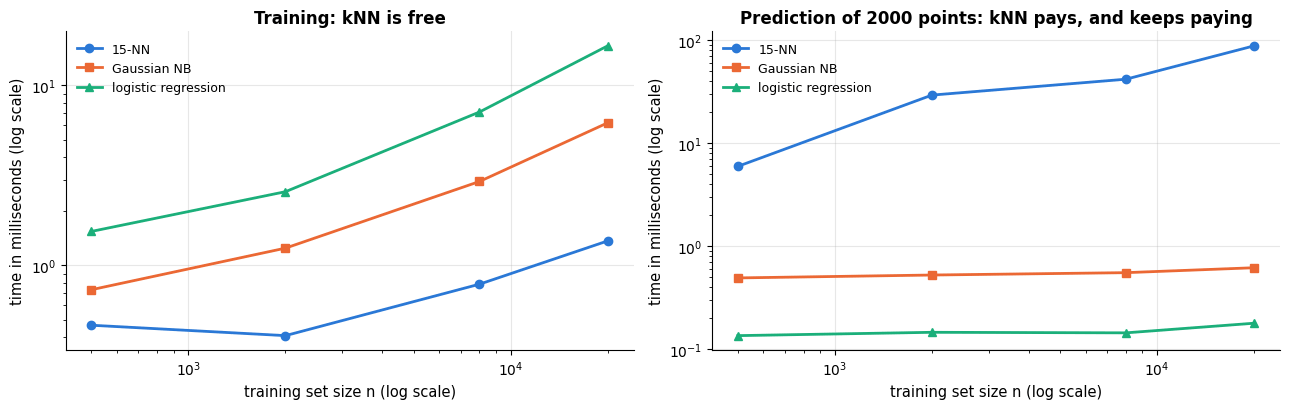

at n = 20000: kNN predicts 2000 points in 88 ms, logistic regression in 0.2 ms (490× faster)


In [25]:
d_cost, n_query_cost = 20, 2000
sizes_cost = [500, 2000, 8000, 20000]
X_q_cost = rng.normal(size=(n_query_cost, d_cost))      # the same 2000 query points for every training size
cost_models = {"15-NN": KNeighborsClassifier(15), "Gaussian NB": GaussianNB(),
               "logistic regression": LogisticRegression(max_iter=1000)}
fit_times = {k: [] for k in cost_models}                # dict comprehension: one empty list per model name
pred_times = {k: [] for k in cost_models}
for n_c in sizes_cost:
    X_c = rng.normal(size=(n_c, d_cost))
    y_c = (X_c[:, 0] + 0.5 * X_c[:, 1] > 0).astype(int)    # a simple linear labelling rule
    for name, model in cost_models.items():
        reps_fit, reps_pred = [], []
        for _ in range(3):                                   # best of three: timings are noisy
            t0 = time.perf_counter(); model.fit(X_c, y_c); reps_fit.append(time.perf_counter() - t0)
            t0 = time.perf_counter(); model.predict(X_q_cost); reps_pred.append(time.perf_counter() - t0)
        fit_times[name].append(min(reps_fit))
        pred_times[name].append(min(reps_pred))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
for (name, _), marker in zip(cost_models.items(), ["o", "s", "^"]):     # (name, _): the model itself is not needed
    axes[0].plot(sizes_cost, 1000 * np.array(fit_times[name]), marker=marker, label=name)      # seconds -> ms
    axes[1].plot(sizes_cost, 1000 * np.array(pred_times[name]), marker=marker, label=name)
for ax, title in zip(axes, ["Training: kNN is free", f"Prediction of {n_query_cost} points: kNN pays, and keeps paying"]):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("training set size n (log scale)")
    ax.set_ylabel("time in milliseconds (log scale)")
    ax.set_title(title)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
# the ratio of the two prediction times; max(..., 1e-9) guards against dividing by a time of 0
print(f"at n = {sizes_cost[-1]}: kNN predicts {n_query_cost} points in {1000 * pred_times['15-NN'][-1]:.0f} ms, "
      f"logistic regression in {1000 * pred_times['logistic regression'][-1]:.1f} ms "
      f"({pred_times['15-NN'][-1] / max(pred_times['logistic regression'][-1], 1e-9):.0f}× faster)")

The left panel is flat for $k$NN at essentially zero (it copies a pointer) and rises for the
two parametric models; the right panel is the mirror image. A model you fit once and query a
billion times should put its cost where logistic regression puts it. That is the real reason
$k$NN is rare in production systems that cannot afford an approximate-nearest-neighbour
index (section 2).

### 7.5 Choosing between them

A short decision rule covers most cases. **Sparse counts or text → multinomial naive
Bayes** (and compare with a linear model, notebook 15). **Numeric features, very little
data, or a baseline you need in one minute → Gaussian naive Bayes**, remembering that its
probabilities are not to be trusted. **Few well-scaled numeric features, an irregular
boundary, and no latency constraint → $k$NN.** With many features and plenty of data, both
lose to the methods of notebooks 9–11; with correlated features that matter, prefer a model
that can see correlations (QDA, logistic regression with interactions, trees).

## 8. Tuning guide

### 8.1 What the knobs do

| Parameter | Model | What it controls | Range / scale | Bias–variance | Default |
|---|---|---|---|---|---|
| `n_neighbors` ($k$) | `KNeighbors*` | how many neighbours vote — the amount of smoothing | 1 … $\sqrt{n}$, **log-ish** grid | ↑ $k$ → more bias, less variance | `5` |
| `weights` | `KNeighbors*` | `"uniform"` or `1/d` weighting of the voters | two values | `"distance"` reduces the bias of large $k$; it also interpolates the training data exactly | `"uniform"` |
| `metric`, `p` | `KNeighbors*` | what "close" means; `p` is the Minkowski power ($p=1$ Manhattan, $2$ Euclidean) | `p` ∈ {1, 1.5, 2, 3}; `"cosine"` for text/embeddings | small effect on bias–variance, large effect on *which* points are neighbours | `"minkowski"`, `p=2` |
| scaler | pipeline | the units the metric sees | `StandardScaler` / `MinMaxScaler` / `RobustScaler` / none | not a bias–variance knob: **mandatory** (7.2) | — |
| `algorithm`, `leaf_size` | `KNeighbors*` | exact search strategy | `auto` | **none — identical predictions**, speed only | `auto`, `30` |
| `var_smoothing` | `GaussianNB` | variance floor, as a fraction of the largest feature variance | $10^{-12} \dots 10^{0}$, **log** | ↑ smoothing → variances equalise, boundary flattens → more bias | `1e-9` |
| `priors` | `GaussianNB` | class prior instead of the observed frequencies | probability vector | shifts the boundary, not its shape | class frequencies |
| `alpha` | `MultinomialNB`, `BernoulliNB` | additive (Laplace/Lidstone) smoothing of the word counts | $10^{-2} \dots 10^{1}$, **log**; `0` is a failure mode | ↑ alpha → flatter word distributions → more bias | `1.0` |
| `fit_prior` | `MultinomialNB` | learn class priors or assume uniform | on / off | matters only for imbalanced classes | `True` |
| vectoriser knobs | `CountVectorizer` | `ngram_range`, `min_df`, `binary`, `sublinear_tf` | see notebook 15 | usually a **larger** effect than `alpha` | — |

### 8.2 Tune in this order

1. **The representation, before any hyper-parameter.** For $k$NN: scale (7.2), then remove or
   compress irrelevant features (section 3.4 — nothing you do to $k$ repairs 100 noise
   dimensions). For multinomial NB: the vectoriser (n-grams, `min_df`, binary counts) moves
   accuracy more than `alpha` does.
2. **`n_neighbors`** — the one knob that matters for $k$NN. Log-spaced grid from 1 to about
   $\sqrt{n}$, one-standard-error rule when the curve is flat (section 1.4).
3. **`weights`**, jointly with $k$: they interact, because distance weighting is what makes a
   large $k$ safe (8.4).
4. **`metric` / `p`**, last and only if the first three left something on the table; switch to
   `"cosine"` *by data type* (text, embeddings) rather than by cross-validation.
5. For naive Bayes: **`alpha`** (multinomial) is worth a quick log grid; **`var_smoothing`**
   (Gaussian) is worth checking mostly as a regularisation knob on small or nearly-degenerate
   data. Do not bother with `algorithm`, `leaf_size` or `fit_prior`.

### 8.3 Validation curves for the parameters that matter

Three curves, one per method, all on the training halves of data we have already met, all
with a $\pm$ 1 standard-error band and the one-standard-error choice marked.

kNN: n_neighbors             best        13 (0.970 ± 0.005)   one-SE        13 (0.970)
GaussianNB: var_smoothing    best     1e-07 (0.932 ± 0.005)   one-SE     1e-07 (0.932)
MultinomialNB: alpha         best     1e-10 (0.974 ± 0.004)   one-SE        10 (0.974)


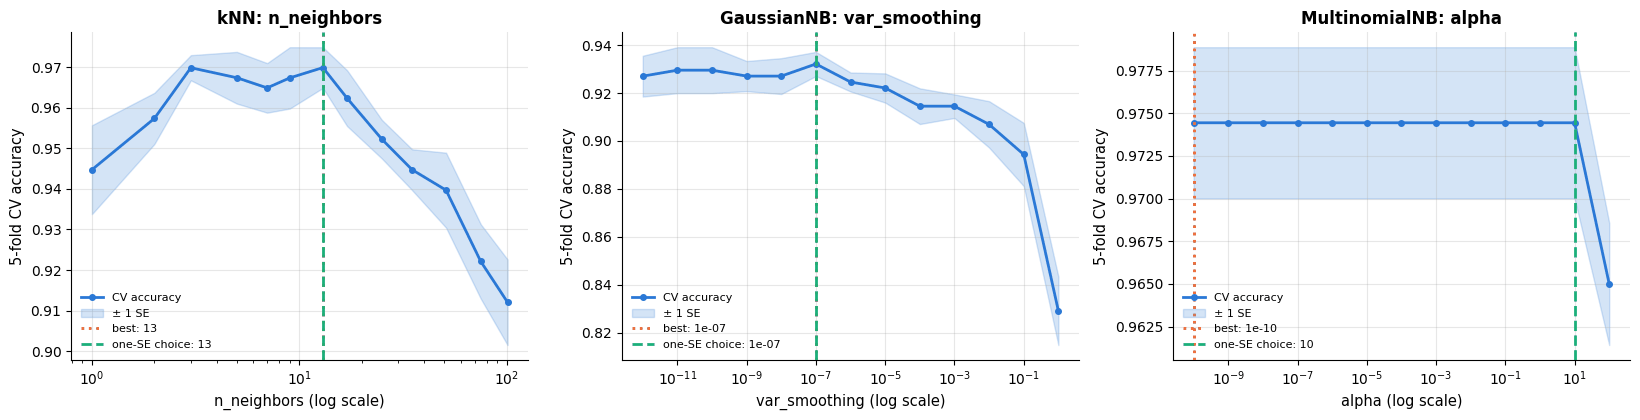

In [26]:
def cv_curve_acc(make_model, values, X, y, cv_obj=None):
    """Mean and standard error of the CV accuracy for every value of one hyper-parameter.

    make_model(v) must return a fresh, unfitted model for the value v; cv_obj defaults to the notebook's
    5-fold `cv`. Returns two arrays (means, standard errors) with one entry per value.
    """
    cv_obj = cv_obj if cv_obj is not None else cv           # a conditional expression: use cv unless one was passed
    means, ses = [], []
    for v in values:
        s = cross_val_score(make_model(v), X, y, cv=cv_obj)
        means.append(s.mean())
        ses.append(s.std(ddof=1) / np.sqrt(len(s)))
    return np.array(means), np.array(ses)

def one_se_simplest(values, means, ses):
    """Index of the best value and of the largest (= simplest/most smoothed) within one SE of it.

    `values` itself is not used: the function works with positions, so the grid must be sorted with the
    most smoothed value last. Returns (best index, one-SE index).
    """
    b = int(np.argmax(means))
    ok = np.where(means >= means[b] - ses[b])[0]    # positions whose mean is within one SE of the best
    return b, int(ok.max())

k_values = np.array([1, 2, 3, 5, 7, 9, 13, 17, 25, 35, 51, 75, 101])
vs_values = np.logspace(-12, 0, 13)                 # 10^-12, 10^-11, ..., 10^0
alpha_values = np.logspace(-10, 2, 13)              # 10^-10, 10^-9, ..., 10^2
# each entry: (title, values, x-axis label, CV means, CV standard errors); the * unpacks the (means, ses)
# pair that cv_curve_acc returns into the last two items of the tuple
curves = [
    # lambda k: ... builds a fresh model for each value; int(k) converts the NumPy integer to a Python int
    ("kNN: n_neighbors", k_values, "n_neighbors (log scale)",
     *cv_curve_acc(lambda k: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=int(k))),
                   k_values, Xc_train, yc_train)),
    ("GaussianNB: var_smoothing", vs_values, "var_smoothing (log scale)",
     *cv_curve_acc(lambda v: GaussianNB(var_smoothing=v), vs_values, Xc_train, yc_train)),
    ("MultinomialNB: alpha", alpha_values, "alpha (log scale)",
     *cv_curve_acc(lambda a: MultinomialNB(alpha=a), alpha_values, C_train, s_train)),
]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.3))
for ax, (title, values, xlabel, mean, se) in zip(axes, curves):
    b, o = one_se_simplest(values, mean, se)
    ax.plot(values, mean, marker="o", ms=4, color=PALETTE[0], label="CV accuracy")
    ax.fill_between(values, mean - se, mean + se, color=PALETTE[0], alpha=0.2, label="± 1 SE")
    ax.axvline(values[b], color=PALETTE[1], ls=":", label=f"best: {values[b]:.3g}")       # :.3g: 3 significant digits
    ax.axvline(values[o], color=PALETTE[2], ls="--", label=f"one-SE choice: {values[o]:.3g}")
    ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("5-fold CV accuracy")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower left")
    print(f"{title:28s} best {values[b]:9.3g} ({mean[b]:.3f} ± {se[b]:.3f})   "
          f"one-SE {values[o]:9.3g} ({mean[o]:.3f})")
plt.tight_layout()
plt.show()

Three different shapes, and each carries a different lesson.

The **$k$NN** curve is the familiar complexity curve of section 1.4: a steep rise to $k = 3$,
a broad plateau from 3 to about 15, then a slow decline as the neighbourhood starts to
swallow the other class. Every value between 3 and 17 is within one standard error of the
best, so the argmax ($k = 13$ here, where the one-standard-error choice happens to land as
well) is not meaningfully better than $k = 5$ — report the plateau, not the winner.

The **`var_smoothing`** curve is flat over five orders of magnitude and then falls away,
gently from $10^{-6}$ and steeply beyond $10^{-1}$, as the variance floor grows past the real
feature variances and flattens the model (8.5 shows what that does to the boundary). The
default $10^{-9}$ sits safely inside the flat region: this is a parameter you *check* on
small or degenerate data, not one you tune.

The **`alpha`** curve is flat to the width of a hair over twelve orders of magnitude, and
that too is a finding. This corpus has a 133-word vocabulary in which every word occurs in
both classes, so there are no zero counts for smoothing to rescue and $\alpha$ has
essentially nothing to do until it becomes large enough (around 100) to wash the word
distributions out. Before spending a grid search on a parameter, it is worth one curve to
find out whether it matters at all. The failure mode promised in 7.1 is real, but it needs a
vocabulary with class-specific words — as any realistic corpus has, and as we can build in
four lines:

In [27]:
toy_docs = ["poor sound poor sound", "poor battery poor", "poor price poor sound", "poor sound poor price",
            "great sound poor", "great battery", "great price sound", "great quality"]
toy_y = np.array([0, 0, 0, 0, 1, 1, 1, 1])           # 0 = negative, 1 = positive
toy_vec = CountVectorizer().fit(toy_docs)            # learn the six-word vocabulary
query = ["poor poor poor quality"]                   # 'quality' never occurs in a negative review
print("vocabulary:", list(toy_vec.get_feature_names_out()))

for a in [1e-10, 1.0]:                               # practically no smoothing, then Laplace smoothing
    nb_toy = MultinomialNB(alpha=a).fit(toy_vec.transform(toy_docs), toy_y)
    probs = nb_toy.predict_proba(toy_vec.transform(query))[0]     # [0]: the row of the only query document
    # {a:<6g}: the number in its shortest form, left-aligned in 6 characters
    print(f"alpha = {a:<6g}  P(negative) = {probs[0]:.4f}   P(positive) = {probs[1]:.4f}   "
          f"-> predicts {'positive' if probs[1] > probs[0] else 'negative'}")

vocabulary: ['battery', 'great', 'poor', 'price', 'quality', 'sound']
alpha = 1e-10   P(negative) = 0.0000   P(positive) = 1.0000   -> predicts positive
alpha = 1       P(negative) = 0.9389   P(positive) = 0.0611   -> predicts negative


The review says "poor" three times, and without smoothing it is classified as **positive**
with probability 1.000. The reason is the single word `quality`, which no negative training
document happened to use: $\hat\theta_{\text{negative},\,\text{quality}} = 0$ makes the
entire product zero, so the negative class is *vetoed* no matter how much other evidence
supports it. With $\alpha = 1$ the same model gets it right, and confidently. That is why
the default is 1 and why `alpha = 0` is a bug rather than a setting — even when, as on the
review corpus above, the validation curve looks perfectly flat.

### 8.4 Two parameters that interact: $k$ with the metric, and $k$ with the weights

`n_neighbors` interacts with everything that changes *which* points are neighbours or *how
much* each one counts. The heat-map below crosses $k$ with the Minkowski power $p$; the
right-hand panel crosses $k$ with `weights`, which is the interaction that actually changes
your choice of $k$.

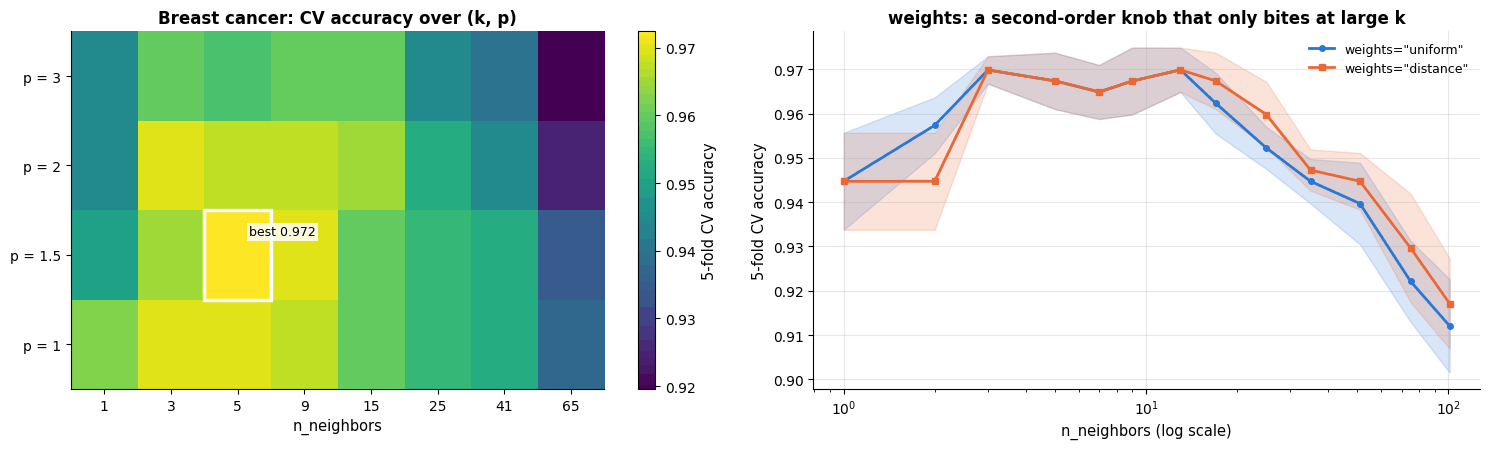

best (k, p) combination: k = 5, p = 1.5, CV accuracy 0.972
spread of CV accuracy across the whole grid: 0.920 – 0.972


In [28]:
p_values = [1, 1.5, 2, 3]                           # Minkowski powers: 1 = Manhattan, 2 = Euclidean
k_grid = np.array([1, 3, 5, 9, 15, 25, 41, 65])
# heat[i, j] = mean CV accuracy for p_values[i] and k_grid[j]: the outer comprehension builds the rows (p),
# the inner one the columns (k)
heat = np.array([[cross_val_score(make_pipeline(StandardScaler(),
                                                KNeighborsClassifier(n_neighbors=int(k), metric="minkowski", p=p)),
                                  Xc_train, yc_train, cv=cv).mean()
                  for k in k_grid] for p in p_values])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
# imshow draws the 2-D array as coloured cells; origin="lower" puts row 0 at the bottom
im = axes[0].imshow(heat, cmap="viridis", aspect="auto", origin="lower")
axes[0].set_xticks(range(len(k_grid)), k_grid)      # tick positions, then their labels
axes[0].set_yticks(range(len(p_values)), [f"p = {p}" for p in p_values])
# argmax gives a position in the flattened array; np.unravel_index turns it into a (row, column) pair
i_b, j_b = np.unravel_index(np.argmax(heat), heat.shape)
# imshow centres cell (i, j) on the point (j, i), so the outline of the best cell starts at (j - 0.5, i - 0.5)
axes[0].add_patch(plt.Rectangle((j_b - 0.5, i_b - 0.5), 1, 1, fill=False, edgecolor="white", lw=2.5))
# textcoords="offset points": xytext is an offset of (8, 14) points from xy; bbox draws a white box behind the text
axes[0].annotate(f"best {heat[i_b, j_b]:.3f}", xy=(j_b, i_b), xytext=(8, 14), textcoords="offset points",
                 fontsize=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5})
axes[0].set_xlabel("n_neighbors")
axes[0].set_title("Breast cancer: CV accuracy over (k, p)")
axes[0].grid(False)
plt.colorbar(im, ax=axes[0], label="5-fold CV accuracy")

for weights, color, marker in [("uniform", PALETTE[0], "o"), ("distance", PALETTE[1], "s")]:
    # the lambda reads `weights` when cv_curve_acc calls it, which happens within this loop iteration
    mean, se = cv_curve_acc(lambda k: make_pipeline(StandardScaler(),
                                                    KNeighborsClassifier(n_neighbors=int(k), weights=weights)),
                            k_values, Xc_train, yc_train)
    axes[1].plot(k_values, mean, marker=marker, ms=4, color=color, label=f'weights="{weights}"')
    axes[1].fill_between(k_values, mean - se, mean + se, color=color, alpha=0.18)
axes[1].set_xscale("log")
axes[1].set_xlabel("n_neighbors (log scale)")
axes[1].set_ylabel("5-fold CV accuracy")
axes[1].set_title("weights: a second-order knob that only bites at large k")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print("best (k, p) combination:", f"k = {k_grid[j_b]}, p = {p_values[i_b]}, CV accuracy {heat[i_b, j_b]:.3f}")
print("spread of CV accuracy across the whole grid:", f"{heat.min():.3f} – {heat.max():.3f}")

Two practical conclusions. First, the heat-map is **structured in $k$ and nearly flat in
$p$**: moving along a row costs up to five points of accuracy, moving down a column costs
one or two (only $p = 3$ is clearly worse — with 30 standardised features, Manhattan,
Euclidean and everything between rank almost the same neighbours). Tune $k$ on a fine grid
and give $p$ three or four values at most. Second, the right-hand panel shows the
interaction with `weights`: the two curves are identical for small $k$ — with few
neighbours there is little to weight — and separate as $k$ grows, where discounting distant
voters recovers about a point of accuracy. The bands still overlap, so on this dataset
`weights` is a second-order knob; but because its benefit *only* appears at large $k$, the
two must be searched together rather than one after the other. Section 8.5 shows the same
interaction on data where it is much stronger.

### 8.5 What the parameters do to the decision boundary

Numbers say which value wins; pictures say what the value *does*. Two small grids: $k$
against `weights` for $k$NN, and `var_smoothing` for Gaussian naive Bayes.

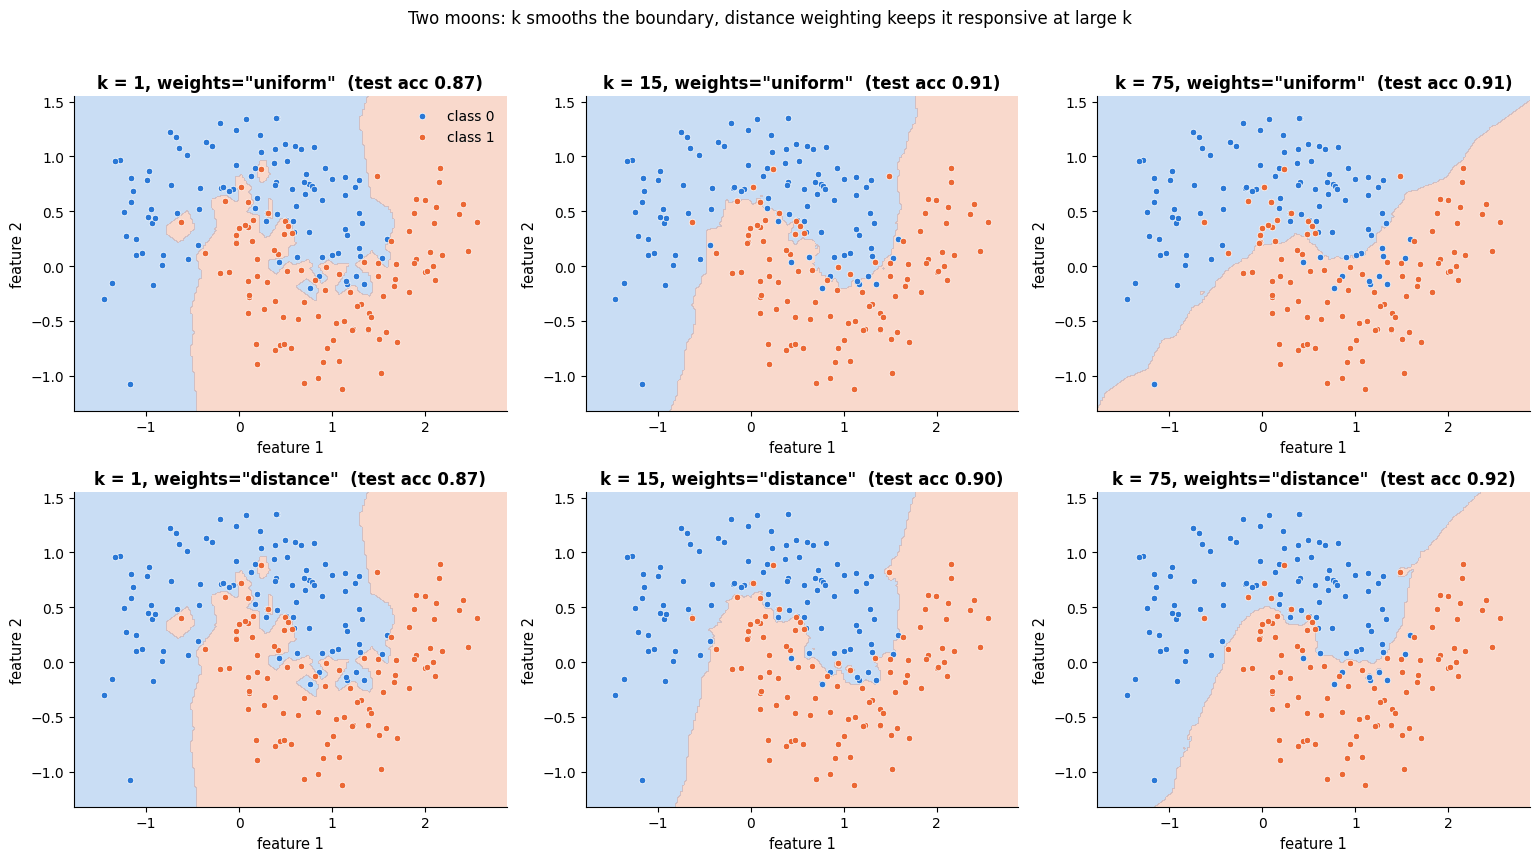

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4))
for row, weights in enumerate(["uniform", "distance"]):
    for col, k in enumerate([1, 15, 75]):
        clf = KNeighborsClassifier(n_neighbors=k, weights=weights).fit(Xm_train, ym_train)
        plot_decision_boundary(clf, Xm_train, ym_train, ax=axes[row, col], resolution=200,
                               title=f'k = {k}, weights="{weights}"  (test acc {clf.score(Xm_test, ym_test):.2f})')
        axes[row, col].legend().set_visible(col == 0 and row == 0)     # show the legend in the top-left panel only
fig.suptitle("Two moons: k smooths the boundary, distance weighting keeps it responsive at large k", y=1.02)
plt.tight_layout()
plt.show()

At $k = 1$ the two rows are identical — with a single neighbour there is nothing to weight.
At $k = 75$, more than a third of the 200 training points, they differ sharply: uniform
voting has flattened the two crescents into a nearly straight boundary, while distance
weighting still bends around the gap between them. This is the interaction of 8.4, drawn.
Remember also what distance weighting does at zero distance: the weight $1/d$ is infinite,
so the fit reproduces every training label exactly and its *training* accuracy is always
100 % — a reason never to judge a distance-weighted $k$NN on training data.

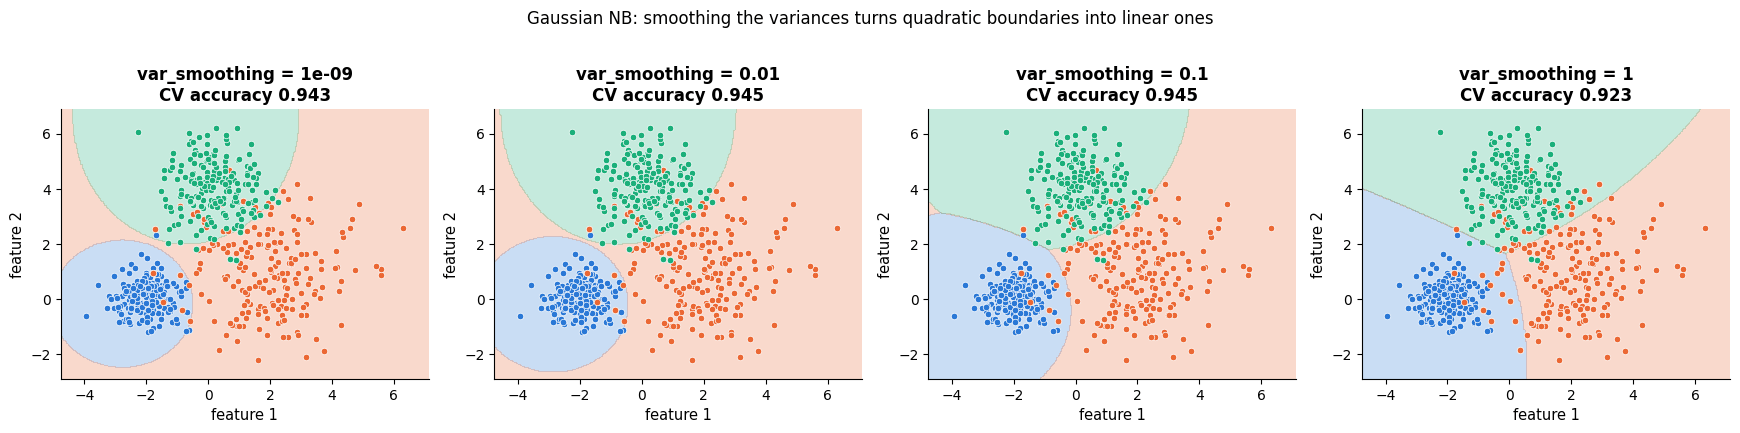

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.2))
for ax, vs in zip(axes, [1e-9, 1e-2, 1e-1, 1.0]):
    model = GaussianNB(var_smoothing=vs).fit(X_blob, y_blob)
    acc = cross_val_score(GaussianNB(var_smoothing=vs), X_blob, y_blob, cv=cv).mean()
    plot_decision_boundary(model, X_blob, y_blob, ax=ax, title=f"var_smoothing = {vs:g}\nCV accuracy {acc:.3f}")
    ax.legend().set_visible(False)
fig.suptitle("Gaussian NB: smoothing the variances turns quadratic boundaries into linear ones", y=1.02)
plt.tight_layout()
plt.show()

The three blobs have deliberately different spreads (0.6, 1.4 and 0.9), and at the default
`var_smoothing` the boundaries are visibly **quadratic** — the wide class claims territory
in a curve around the narrow ones. As the smoothing grows, all variances converge to the
same value and the quadratic terms cancel: the boundaries straighten into the linear
discriminant of notebook 14. That is the whole geometric content of the parameter, and it
explains the shape of the validation curve in 8.3: nothing happens until the floor reaches
the real variances, and then the model class itself changes.

### 8.6 Practical notes

- **What to tune first.** For $k$NN, the scaler and $k$; everything else is a refinement.
  For multinomial NB, the vectoriser and then `alpha`. For Gaussian NB, nothing — check
  `var_smoothing` on small or degenerate data and move on.
- **What not to tune.** `algorithm` and `leaf_size` change the *speed* of an exact search,
  never its result (section 2); `fit_prior` matters only under class imbalance.
- **Edges and flats.** If the best $k$ is at the top of your grid, the model wants more
  smoothing than you offered — extend it towards $n/2$ and suspect that the features are
  uninformative. If the curve is flat (it usually is over a wide middle), take the
  one-standard-error choice: a larger $k$ is cheaper at prediction time *and* more stable.
- **Cost.** A $k$NN grid search is deceptively expensive: every candidate re-queries every
  validation point, so the cost is $O(|\text{grid}| \times k_\text{folds} \times n^2 d)$. Use
  a coarse log grid first, and remember that `GridSearchCV` with `n_jobs=-1` is the easy win.
- **Use a pipeline.** The scaler must be fitted inside each fold; `make_pipeline` plus
  `param_grid={"kneighborsclassifier__n_neighbors": ...}` is the only safe way to tune a
  distance-based model (notebooks 4 and 12).

## 9. Case study on real data

Two applications, one per family, both on datasets we can load offline. The first is
genuinely real; the second is honest about not being.

### 9.1 $k$NN on the breast cancer data: does scaling matter? (yes)

The **Wisconsin breast cancer** data (Street, Wolberg & Mangasarian, 1993) are 569 fine-needle
aspirates of breast masses, each summarised by 30 features — the mean, standard error and
"worst" value of ten cell-nucleus measurements (radius, texture, perimeter, area, smoothness,
…) — labelled benign (357) or malignant (212). The features are on wildly different scales:
`mean area` runs into the thousands, `mean smoothness` is around 0.1. That is exactly the
situation of 7.2, so the first experiment is not about $k$ at all.

569 patients, 30 features; 357 benign, 212 malignant
training split 398 patients, test split 171 (stratified, from section 4.5)
feature scales: mean area ≈ 655, mean smoothness ≈ 0.0964, mean radius ≈ 14.1


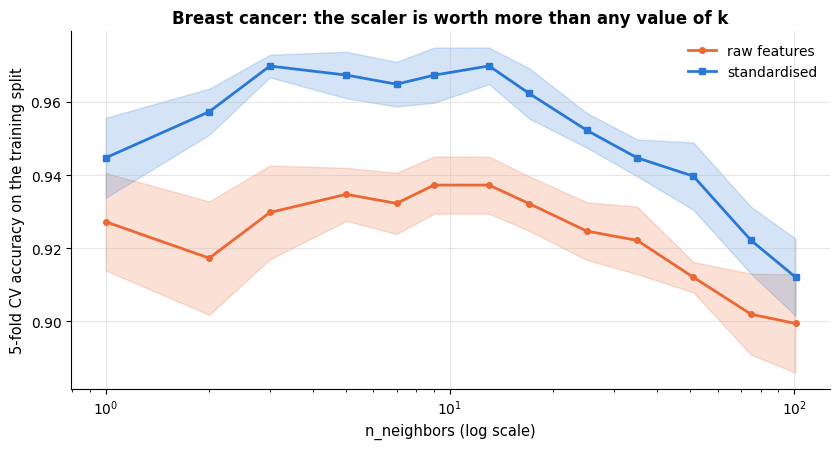

raw features   best CV accuracy 0.937 at k = 9
standardised   best CV accuracy 0.970 at k = 13


In [31]:
print(f"{cancer.data.shape[0]} patients, {cancer.data.shape[1]} features; "
      f"{int((cancer.target == 1).sum())} benign, {int((cancer.target == 0).sum())} malignant")
print(f"training split {Xc_train.shape[0]} patients, test split {Xc_test.shape[0]} (stratified, from section 4.5)")
# columns 3, 4 and 0 are mean area, mean smoothness and mean radius; ", ".join(...) glues the
# "name ≈ value" strings together with commas
print("feature scales:", ", ".join(f"{n} ≈ {v:.3g}" for n, v in
                                   zip(cancer.feature_names[[3, 4, 0]], cancer.data[:, [3, 4, 0]].mean(axis=0))))

scaling_curves = {}
# each factory is a function k -> unfitted model: without a scaler, and with one
for label, factory in [("raw features", lambda k: KNeighborsClassifier(n_neighbors=int(k))),
                       ("standardised", lambda k: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=int(k))))]:
    scaling_curves[label] = cv_curve_acc(factory, k_values, Xc_train, yc_train)     # a (means, ses) pair

fig, ax = plt.subplots(figsize=(8.5, 4.6))
# zip walks the dict items together with the colours and markers; (label, (mean, se)) unpacks each item
for (label, (mean, se)), color, marker in zip(scaling_curves.items(), [PALETTE[1], PALETTE[0]], ["o", "s"]):
    ax.plot(k_values, mean, marker=marker, ms=4, color=color, label=label)
    ax.fill_between(k_values, mean - se, mean + se, color=color, alpha=0.2)
ax.set_xscale("log")
ax.set_xlabel("n_neighbors (log scale)")
ax.set_ylabel("5-fold CV accuracy on the training split")
ax.set_title("Breast cancer: the scaler is worth more than any value of k")
ax.legend()
plt.tight_layout()
plt.show()
for label, (mean, se) in scaling_curves.items():
    print(f"{label:14s} best CV accuracy {mean.max():.3f} at k = {k_values[int(np.argmax(mean))]}")

Across the whole useful range of $k$ the standardised curve runs three to four points above
the raw one, and the two error bands are separated everywhere between $k = 3$ and $k = 51$.
The best raw model (0.937 at $k = 9$) is worse than *every* standardised model with
$3 \le k \le 35$. Tuning $k$ cannot compensate for a metric in which `area` (hundreds)
drowns out `smoothness` (0.1): the biggest single improvement available here is one line of
preprocessing, not one line of hyper-parameters. (At the far right both curves collapse
together, for the same reason: a neighbourhood of 100 patients is too big no matter how you
scale it.)

### 9.2 Tuning, and an honest test-set evaluation

Now the guide from section 8: $k$ and `weights` searched together, `p` given four values,
everything inside a pipeline, all of it on the training split. The test patients are touched
exactly once, at the end.

In [32]:
from sklearn.model_selection import GridSearchCV     # cross-validates every combination in a grid of settings
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier            # trivial baselines; "most_frequent" always predicts the majority

# make_pipeline names each step after its class in lower case, so a parameter of the kNN step is addressed as
# "kneighborsclassifier__<parameter>"; the grid has 9 x 2 x 2 = 36 combinations, each scored by 5-fold CV
knn_grid = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()),
                        {"kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 13, 17, 25, 35],
                         "kneighborsclassifier__weights": ["uniform", "distance"],
                         "kneighborsclassifier__p": [1, 2]},
                        cv=cv, n_jobs=1).fit(Xc_train, yc_train)       # n_jobs=1: run in a single process
# best_params_ is a dict of the winning settings; k.split("__")[-1] strips the step-name prefix from each key
print("best parameters:", {k.split("__")[-1]: v for k, v in knn_grid.best_params_.items()},
      f"  CV accuracy {knn_grid.best_score_:.3f}")

contenders = {"majority baseline": DummyClassifier(strategy="most_frequent"),
              "tuned kNN": knn_grid.best_estimator_,              # the best pipeline, refitted on all training data
              "Gaussian NB": GaussianNB(),
              "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))}
for name, model in contenders.items():
    model.fit(Xc_train, yc_train)
    # ROC AUC from P(class 1); hasattr checks that the model has predict_proba (otherwise NaN)
    auc = roc_auc_score(yc_test, model.predict_proba(Xc_test)[:, 1]) if hasattr(model, "predict_proba") else np.nan
    print(f"{name:20s} test accuracy {model.score(Xc_test, yc_test):.3f}   ROC AUC {auc:.3f}")
print()
# per-class precision, recall and F1; target_names gives the printed names of classes 0 and 1
print(classification_report(yc_test, contenders["tuned kNN"].predict(Xc_test),
                            target_names=["malignant", "benign"], digits=3))

best parameters: {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}   CV accuracy 0.972
majority baseline    test accuracy 0.626   ROC AUC 0.500
tuned kNN            test accuracy 0.959   ROC AUC 0.986
Gaussian NB          test accuracy 0.947   ROC AUC 0.990
logistic regression  test accuracy 0.988   ROC AUC 0.998

              precision    recall  f1-score   support

   malignant      1.000     0.891     0.942        64
      benign      0.939     1.000     0.968       107

    accuracy                          0.959       171
   macro avg      0.969     0.945     0.955       171
weighted avg      0.962     0.959     0.959       171



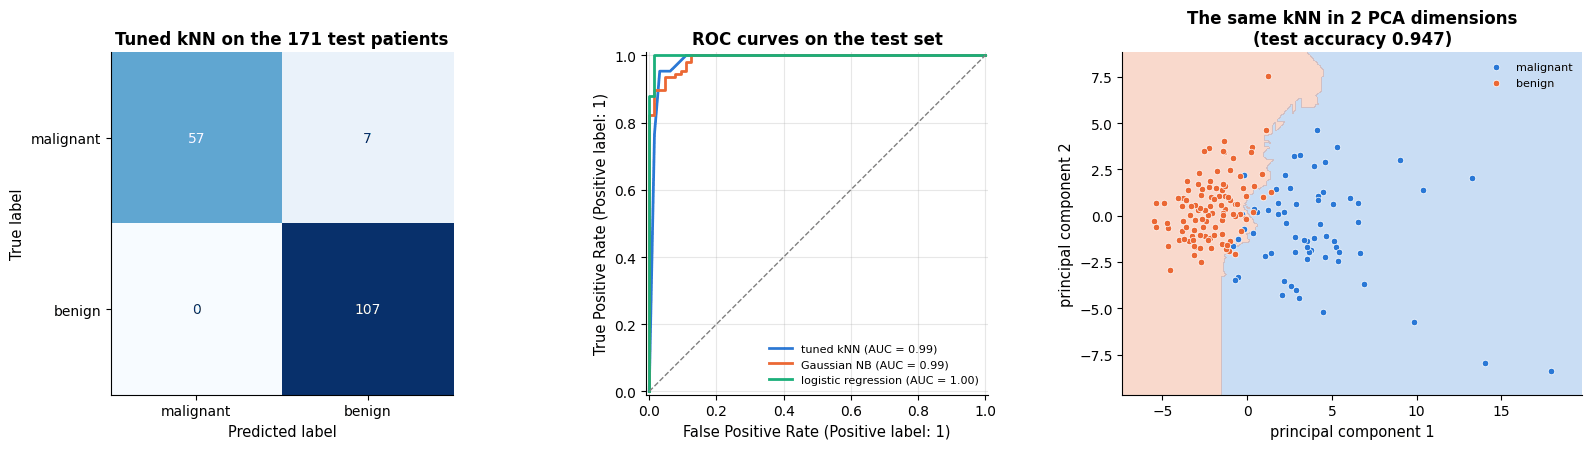

In [33]:
from sklearn.decomposition import PCA              # principal component analysis (notebook 14)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
# from_estimator predicts on the test data and draws the confusion matrix (rows = true, columns = predicted)
ConfusionMatrixDisplay.from_estimator(contenders["tuned kNN"], Xc_test, yc_test, ax=axes[0], cmap="Blues",
                                      display_labels=["malignant", "benign"], colorbar=False)
axes[0].set_title("Tuned kNN on the 171 test patients")
axes[0].grid(False)
for name in ["tuned kNN", "Gaussian NB", "logistic regression"]:
    RocCurveDisplay.from_estimator(contenders[name], Xc_test, yc_test, ax=axes[1], name=name)   # one ROC curve each
axes[1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
axes[1].set_title("ROC curves on the test set")
axes[1].legend(fontsize=8, loc="lower right")

# scale, project the 30 features onto 2 principal components, then the tuned kNN;
# ** unpacks the dict of best parameters into keyword arguments, e.g. n_neighbors=7
pca_knn = make_pipeline(StandardScaler(), PCA(n_components=2),
                        KNeighborsClassifier(**{k.split("__")[-1]: v for k, v in knn_grid.best_params_.items()}))
pca_knn.fit(Xc_train, yc_train)
Z_test = pca_knn[:-1].transform(Xc_test)           # pca_knn[:-1] is the pipeline without its last step: scaler + PCA
# pca_knn[-1] is the fitted kNN step, drawn in the 2-D PCA plane over the test patients
plot_decision_boundary(pca_knn[-1], Z_test, yc_test, ax=axes[2],
                       title=f"The same kNN in 2 PCA dimensions\n(test accuracy {pca_knn.score(Xc_test, yc_test):.3f})",
                       feature_names=("principal component 1", "principal component 2"))
axes[2].legend(["malignant", "benign"], fontsize=8, loc="upper right")    # rename the "class 0" / "class 1" entries
plt.tight_layout()
plt.show()

The tuned $k$NN reaches 95.9 % accuracy and a ROC AUC of 0.986 on the 171 held-out
patients — far above the 62.6 % majority baseline, a little ahead of Gaussian naive Bayes on
accuracy (94.7 %), and **behind plain logistic regression** (98.8 %, AUC 0.998). That last
comparison is the honest headline: on 30 correlated, well-behaved numeric features a linear
model is both better and a thousand times faster to query (7.4), and a good report says so.
Notice also that Gaussian naive Bayes, whose independence assumption is badly violated here
(radius, perimeter and area of the same nucleus are near-duplicates of one another — the
situation of section 4.5), still *ranks* patients well: its AUC of 0.990 is higher than
$k$NN's even though its accuracy is lower, exactly the "ranking survives, calibration does
not" pattern of 4.5.

The confusion matrix carries the number a clinician would ask about first. All seven errors
are in the same direction: malignant masses called benign, with not a single benign mass
called malignant. For a screening tool that is the expensive direction, and it is a
consequence of the default 0.5 threshold on a problem with asymmetric costs; notebook 7,
section 5, shows how to move the threshold deliberately instead of accepting it.

The third panel is worth a pause. Two principal components — 2 numbers instead of 30 —
keep almost all of the accuracy (0.947 against 0.959 in the full space), and the $k$NN
boundary drawn in that plane is smooth and sensible. That is the "blessing of structure" of section 3 in action: the
*intrinsic* dimension of these 30 measurements is far smaller than 30, which is exactly why
a distance-based method works at all on this data. (Notebook 14 develops PCA properly.)

### 9.3 Multinomial naive Bayes on product reviews

For the text half we use the review corpus bundled with the course. **Be clear about what it
is: 2 400 short product reviews generated by a script**, not scraped from a shop. It is
excellent for teaching — the vocabulary is small, the ground truth is known and the whole
pipeline runs in seconds — but the accuracies below are optimistic compared with real
reviews, where sarcasm, typos, mixed opinions and a vocabulary a thousand times larger all
push scores down. When you are online, `load_newsgroups()` (a real corpus) is the drop-in
replacement, and notebook 15 runs the same pipeline on it.

best naive Bayes pipeline: MultinomialNB (tf–idf);  tuned alpha = 0.01 (CV accuracy 0.975)
test accuracy of the tuned text model: 0.973


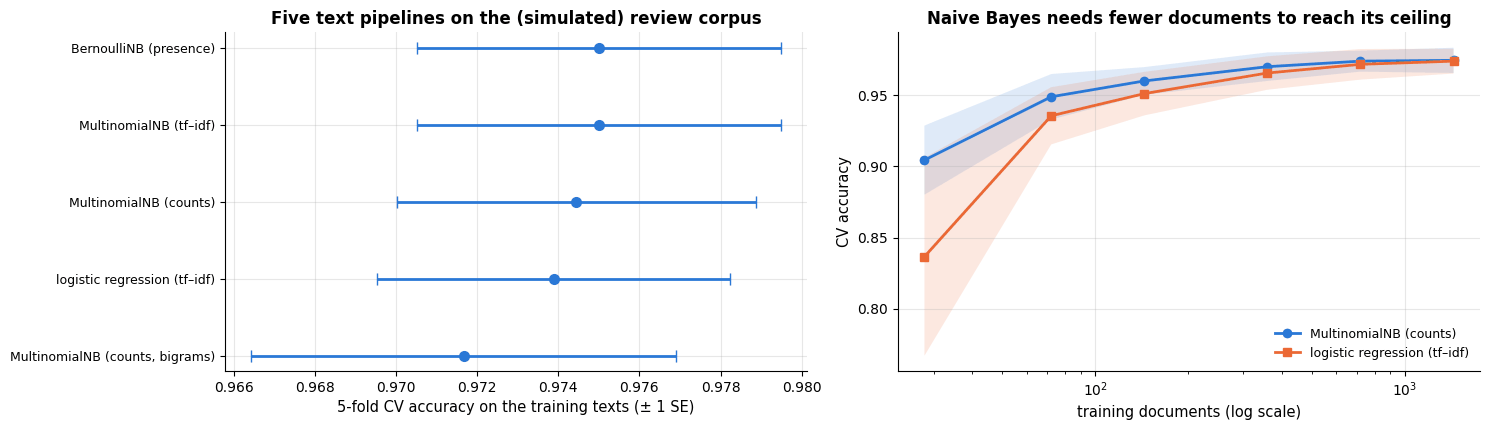

In [34]:
# TfidfVectorizer: like CountVectorizer, but down-weights words that occur in many documents (notebook 15)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline              # like make_pipeline, but you name every step yourself

# ngram_range=(1, 2): count single words and pairs of adjacent words; binary=True: 1 if the word occurs, else 0
text_models = {
    "MultinomialNB (counts)": Pipeline([("vec", CountVectorizer()), ("clf", MultinomialNB(alpha=1.0))]),
    "MultinomialNB (tf–idf)": Pipeline([("vec", TfidfVectorizer()), ("clf", MultinomialNB(alpha=1.0))]),
    "MultinomialNB (counts, bigrams)": Pipeline([("vec", CountVectorizer(ngram_range=(1, 2))), ("clf", MultinomialNB(alpha=1.0))]),
    "BernoulliNB (presence)": Pipeline([("vec", CountVectorizer(binary=True)), ("clf", BernoulliNB(alpha=1.0))]),
    "logistic regression (tf–idf)": Pipeline([("vec", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=2000))]),
}
text_rows = []
for name, model in text_models.items():
    s = cross_val_score(model, text_train, s_train, cv=cv)      # the vectoriser is refitted inside every fold
    text_rows.append({"model": name, "CV accuracy": s.mean(), "SE": s.std(ddof=1) / np.sqrt(len(s))})
text_df = pd.DataFrame(text_rows).set_index("model").sort_values("CV accuracy")     # ascending accuracy

nb_only = text_df.drop(index="logistic regression (tf–idf)")          # only the NB pipelines have an alpha
best_text_name = nb_only["CV accuracy"].idxmax()                      # idxmax: the row label of the largest value
# "clf__alpha" addresses the alpha of the step named "clf"; 10 log-spaced values from 0.01 to 10
alpha_search = GridSearchCV(text_models[best_text_name], {"clf__alpha": np.logspace(-2, 1, 10)},
                            cv=cv, n_jobs=1).fit(text_train, s_train)
final_text = alpha_search.best_estimator_          # the best pipeline, refitted on all the training texts
print(f"best naive Bayes pipeline: {best_text_name};  tuned alpha = {alpha_search.best_params_['clf__alpha']:.3g} "
      f"(CV accuracy {alpha_search.best_score_:.3f})")
print(f"test accuracy of the tuned text model: {final_text.score(text_test, s_test):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
# errorbar draws one dot per model at its CV accuracy, with a horizontal bar of ± 1 SE (xerr); capsize: bar ends
axes[0].errorbar(text_df["CV accuracy"], np.arange(len(text_df)), xerr=text_df["SE"], fmt="o",
                 color=PALETTE[0], capsize=4, ms=7)
axes[0].set_yticks(np.arange(len(text_df)), text_df.index, fontsize=9)
axes[0].set_xlabel("5-fold CV accuracy on the training texts (± 1 SE)")
axes[0].set_title("Five text pipelines on the (simulated) review corpus")
for (name, model), marker in zip([("MultinomialNB (counts)", text_models["MultinomialNB (counts)"]),
                                  ("logistic regression (tf–idf)", text_models["logistic regression (tf–idf)"])],
                                 ["o", "s"]):
    # validation scores for growing training sets, as in section 5
    sizes, _, test_scores = learning_curve(model, text_train, s_train,
                                           train_sizes=np.array([0.02, 0.05, 0.1, 0.25, 0.5, 1.0]),
                                           cv=cv, shuffle=True, random_state=RANDOM_STATE)
    axes[1].plot(sizes, test_scores.mean(axis=1), marker=marker, label=name)
    # a band of ± 1 standard deviation across the folds
    axes[1].fill_between(sizes, test_scores.mean(axis=1) - test_scores.std(axis=1),
                         test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.15)
axes[1].set_xscale("log")
axes[1].set_xlabel("training documents (log scale)")
axes[1].set_ylabel("CV accuracy")
axes[1].set_title("Naive Bayes needs fewer documents to reach its ceiling")
axes[1].legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

Two things to read off. The first panel says that on this corpus every bag-of-words model
lands within *half a percentage point* of every other, well inside the error bars: counts or
TF–IDF, unigrams or bigrams, naive Bayes or logistic regression, it makes no difference. With
a 133-word vocabulary and unambiguous sentiment words the problem is simply easy — a property
of the *simulated* data, not a general truth about text (on real corpora the same comparison
usually separates the models by several points, and TF–IDF with a linear model tends to win). The learning curve says something that does transfer: with a few dozen
documents naive Bayes is already near its ceiling while logistic regression is still
climbing — the Ng & Jordan (2002) pattern of section 5, reproduced on text, which is exactly
why naive Bayes remains the right first model when labelled documents are scarce.

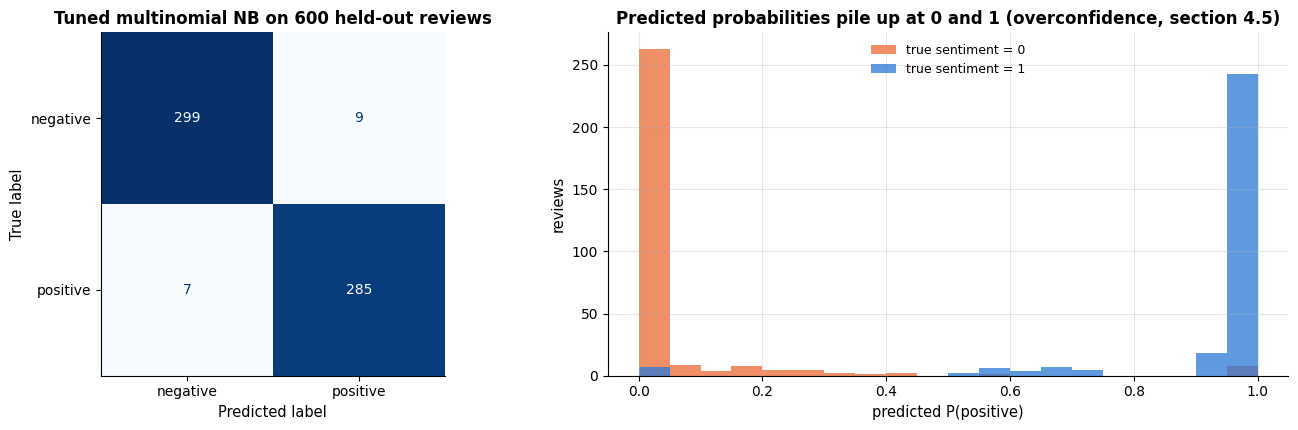

share of test reviews with a predicted probability above 0.99 or below 0.01: 62.7%


In [35]:
proba_text = final_text.predict_proba(text_test)[:, 1]     # P(positive) for every test review
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
ConfusionMatrixDisplay.from_estimator(final_text, text_test, s_test, ax=axes[0], cmap="Blues",
                                      display_labels=["negative", "positive"], colorbar=False)
axes[0].set_title(f"Tuned multinomial NB on {len(s_test)} held-out reviews")
axes[0].grid(False)
for label, color in [(0, PALETTE[1]), (1, PALETTE[0])]:
    # np.asarray(s_test) == label: a boolean mask over the test reviews of one true class;
    # range=(0, 1) makes the 20 bins span exactly [0, 1]
    axes[1].hist(proba_text[np.asarray(s_test) == label], bins=20, range=(0, 1), alpha=0.75, color=color,
                 label=f"true sentiment = {label}")
axes[1].set_xlabel("predicted P(positive)")
axes[1].set_ylabel("reviews")
axes[1].set_title("Predicted probabilities pile up at 0 and 1 (overconfidence, section 4.5)")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
# | is element-wise "or"; the mean of a boolean array is the fraction of True; :.1% prints it as a percentage
print(f"share of test reviews with a predicted probability above 0.99 or below 0.01: "
      f"{np.mean((proba_text > 0.99) | (proba_text < 0.01)):.1%}")

The confusion matrix is nearly diagonal — 16 mistakes in 600 reviews, split evenly between
the two directions — and the histogram shows the familiar naive Bayes signature: about two
thirds of the predictions sit above 0.99 or below 0.01, because every sentiment-bearing word
in a review is counted as independent evidence. The *classification* is fine; the
*probabilities* are not. If a downstream rule said "send everything we are less than 80 %
sure about to a human", this model would send almost nothing — including some of the reviews
it gets wrong. Wrap it in `CalibratedClassifierCV` (notebook 7) before any decision depends
on the number rather than the label.

> **What you would tell the stakeholders.** *For the clinic:* "the model sorts biopsies into
> benign and malignant correctly for about 24 of every 25 patients in a held-out sample of
> 171, and it ranks patients by risk almost perfectly (AUC 0.99). It works by finding the
> most similar past cases in the database, so every prediction can be shown with the cases
> behind it, which is easy to audit. It needs all 30 measurements, in the same units, to
> work at all. Two caveats we would not hide: all seven of its mistakes were malignant
> masses called benign, so it must never be used to rule out disease on its own; and a plain
> logistic regression on the same measurements did better still (two errors in 171 patients)
> and answers a thousand times faster, so that is what we would actually deploy, keeping the
> neighbour model as the explanation layer." *For the review team:* "the word-counting model
> agrees with human labels about 97 times in 100, re-trains in under a second on a laptop,
> and can show you the words that drove each decision. Two caveats: we tested it on a
> simulated corpus, so expect a drop on live reviews with sarcasm, typos and a much larger
> vocabulary; and its confidence numbers are not trustworthy — use the label, never the
> probability, and re-measure on a few hundred hand-labelled real reviews before switching
> anything on."

## Summary

- **$k$NN** predicts by majority vote / averaging over the $k$ closest training points.
  It has no training phase, one hyper-parameter $k$ that controls bias vs. variance, and
  it depends entirely on a *meaningful distance*: scale the features, choose the metric
  for the data type (Euclidean for numeric, cosine for text/embeddings).
- The **Cover–Hart bound** says the 1-NN error is at most twice the Bayes error with
  unlimited data, and $k$NN with $k \to \infty$, $k/n \to 0$ is universally consistent.
- Prediction is $O(nd)$ per query by brute force; **KD/ball trees** make it logarithmic in
  low dimensions and useless in high ones; approximate search (HNSW, FAISS) scales to
  billions of points.
- The **curse of dimensionality**: volume concentrates in corners and shells, distances
  concentrate around their mean, and local neighbourhoods need exponentially many samples.
  Irrelevant features poison distances; real data are saved by low intrinsic dimension.
- **Naive Bayes** models $P(\mathbf{x} \mid y)$ as a product of one-dimensional
  distributions (Gaussian, multinomial, Bernoulli) and applies Bayes' theorem; it trains in
  one pass, is a *linear* classifier in log space, works surprisingly well for
  classification despite false independence assumptions, but produces overconfident,
  poorly calibrated probabilities (calibrate them if you need them).
- **Generative vs. discriminative**: naive Bayes converges fast to a biased asymptote,
  logistic regression converges slowly to a better one.
- Neighbour distances double as **density estimates** (KDE, $k$NN density) and as
  **anomaly scores**.
- **Where they break** (section 7): $k$NN believes your units, so an unscaled metric can
  cost more accuracy than any hyper-parameter can recover, and it moves all of its cost to
  prediction time; naive Bayes is blind to information that lives in the *correlation*
  between features — on data where the classes differ only in that correlation it is exactly
  at chance, while QDA and $k$NN solve the problem.
- **Tuning** (section 8): fix the representation first (scale for $k$NN, the vectoriser for
  text), then `n_neighbors` together with `weights`, then the metric. `var_smoothing` is flat
  over five orders of magnitude — check it, do not tune it — and `alpha` matters only when
  the vocabulary has class-specific words, though then it matters absolutely (`alpha=0`
  lets one unseen word veto a class).
- **On real data** (section 9): a tuned $k$NN diagnoses breast masses correctly for 24 of 25
  held-out patients, but plain logistic regression does better and answers a thousand times
  faster — reporting that honestly is part of the job. Multinomial naive Bayes classifies the
  review corpus almost perfectly and its probabilities are still not to be believed.

| Situation | Reach for |
|---|---|
| Small $n$, few (scaled) features, irregular boundary | `KNeighborsClassifier` / `KNeighborsRegressor`, tune $k$ and `weights` by CV |
| Text / count features, need a fast strong baseline | `CountVectorizer` + `MultinomialNB` (tune `alpha`); compare with `LogisticRegression` |
| Numeric features, a model in one line | `GaussianNB` (no scaling needed) |
| You need probabilities from NB | `CalibratedClassifierCV(GaussianNB(), method="isotonic")` |
| Many irrelevant features, $d \gg 100$ | feature selection / PCA first (notebooks 4, 14), or a parametric model |
| Huge $n$, low latency | approximate nearest neighbours (FAISS, Annoy, HNSW) |
| Density / anomaly score | `KernelDensity`, $k$-th neighbour distance, `LocalOutlierFactor` (notebook 13) |
| Tuning $k$NN | `GridSearchCV` over `n_neighbors` × `weights` (× `p`) inside a scaling pipeline; one-SE rule |
| Information in a *correlation* | not naive Bayes — use QDA, a linear model with interactions, or a tree (notebook 9) |

**Next steps:** notebook 9 (decision trees) introduces the other great non-parametric
family, which is immune to feature scaling and to irrelevant features; notebook 11 (SVMs and
kernels) turns the idea of similarity into kernel functions; notebook 13 (clustering and
anomaly detection) and notebook 14 (dimensionality reduction) build on the distance and
density ideas of this notebook; notebook 15 (NLP) returns to naive Bayes with TF–IDF
features and n-grams.

## Exercises

### Exercise 1 — Weighted $k$NN regression (easy)
Add `weights="distance"` to `KNNRegressorScratch` (it already supports it through the
parent class) and compare uniform and distance-weighted fits on the sine data for
$k \in \{5, 25\}$, both visually and by test MSE on 1 000 fresh points. When does weighting
help, and what happens to the distance-weighted fit exactly *at* a training point?

<details><summary>Solution sketch</summary>

Weighting reduces the bias of large-$k$ fits (far neighbours count less), so $k = 25$ with
distance weights is close to $k = 5$ uniform. At a training point the weight $1/0$ is
infinite: the fit interpolates the training targets exactly, so training error is zero —
distance-weighted $k$NN always "overfits" the training set even for large $k$; evaluate it
on held-out data only.
</details>

### Exercise 2 — Curse of dimensionality, continued (easy)
Repeat the distance-concentration experiment of section 3.2 with standard normal instead of
uniform coordinates, and with a Manhattan instead of a Euclidean distance. Does the
$1/\sqrt{d}$ law still hold? Then compute, for $d \in \{2, 10, 100\}$, how often the nearest
neighbour of a query is *also* one of the $k = 10$ nearest neighbours of many *other*
points ("hubness").

<details><summary>Solution sketch</summary>

The law holds for any i.i.d. coordinates and any $\ell_p$ distance (the argument was a
sum of $d$ i.i.d. terms). Hubness: count for each training point how many times it appears
in the 10-NN lists of the others (`NearestNeighbors(11).kneighbors`, then `np.bincount`);
in high $d$ the distribution becomes very skewed — a few "hub" points are everybody's
neighbour, which further degrades $k$NN.
</details>

### Exercise 3 — Multinomial naive Bayes from scratch (medium)
Implement `MultinomialNBScratch` with additive smoothing $\alpha$: `fit` computes
$\log \hat\pi_c$ and $\log \hat\theta_{cj}$ from the sparse count matrix (`C_train`
supports `C_train[mask].sum(axis=0)`), `predict_log_proba` computes
$\log \hat\pi_c + \mathbf{x}^\top \log \hat{\boldsymbol\theta}_c$ and normalises with the
log-sum-exp trick. Check `feature_log_prob_` and the predictions against
`MultinomialNB(alpha=1.0)`.

<details><summary>Solution sketch</summary>

```py
counts = np.array([np.asarray(C_train[s_train.to_numpy() == c].sum(axis=0)).ravel() for c in (0, 1)])   # N_cj
feature_log_prob = np.log((counts + alpha) / (counts.sum(axis=1, keepdims=True) + alpha * counts.shape[1]))
class_log_prior = np.log(np.bincount(s_train) / len(s_train))
jll = C_test @ feature_log_prob.T + class_log_prior          # (n_docs, 2)
log_proba = jll - scipy.special.logsumexp(jll, axis=1, keepdims=True)
```
Both quantities agree with scikit-learn to machine precision.
</details>

### Exercise 4 — Unregularised logistic regression vs. naive Bayes (medium)
Ng & Jordan used logistic regression *without* regularisation. Redo the learning-curve
experiment of section 5 on the digits with `LogisticRegression(C=1e6, max_iter=5000)`
(effectively unregularised) and with `C=1`. At which training-set sizes does naive Bayes
now beat logistic regression? Explain the difference with the bias–variance vocabulary of
notebook 5.

<details><summary>Solution sketch</summary>

Without regularisation the discriminative model has much higher variance at small $n$
(with 64 features and 30 examples it separates the training set perfectly in many ways),
so its curve starts lower and naive Bayes wins for the smallest sizes; at large $n$ both
logistic regressions converge to ≈ 0.97 while NB stays at ≈ 0.85. Regularisation is a way
to give the discriminative model some of the data efficiency of the generative one.
</details>

### Exercise 5 — Cosine $k$NN for text (medium)
Classify the reviews with `KNeighborsClassifier(metric="cosine")` on TF–IDF features
(`TfidfVectorizer`) for $k \in \{1, 5, 15, 51\}$, and with Euclidean distance on raw
counts. Compare with multinomial NB. Why is cosine distance more appropriate than
Euclidean for bag-of-words vectors?

<details><summary>Solution sketch</summary>

Euclidean distance on counts is dominated by document *length* (a long positive review is
"far" from a short positive review); cosine distance compares directions only. Cosine
$k$NN with $k \approx 15$ should get within a few points of naive Bayes on this corpus,
Euclidean-on-counts noticeably worse. NB remains faster and better calibrated for ranking
by class evidence; $k$NN needs no independence assumption.
</details>

### Exercise 6 — Nearest-neighbour search at scale (hard)
Generate $n = 200\,000$ standard normal points in $d = 3$ and in $d = 100$. For each,
time `NearestNeighbors(algorithm=...)` build and query (1 000 queries) for `brute`,
`kd_tree`, `ball_tree`; then implement a crude *approximate* search: project the data on
$m = 16$ random directions (`rng.normal(size=(d, 16))`), find the 100 nearest candidates in
the projected space with a KD-tree, and re-rank them exactly. Measure recall of the true
5 nearest neighbours and the speed-up.

<details><summary>Solution sketch</summary>

In $d = 3$ the KD-tree wins by ~100×; in $d = 100$ brute force wins. The random-projection
candidate filter (a Johnson–Lindenstrauss argument, notebook 14) keeps most of the true
neighbours at a fraction of the cost: with 100 candidates the recall is typically above
0.9 and the query is several times faster than brute force. Real systems (HNSW, FAISS)
use smarter index structures but the same trade-off between recall and speed.
</details>

## References and further reading

### Textbooks

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — §2.3–2.5 (nearest neighbours, the curse of dimensionality, the $r^{1/d}$ argument) and chapter 13 (prototype methods and nearest neighbours) are the backbone of sections 1–3.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free) — Chapter 2 introduces $k$NN as the model-free counterpart of linear models, chapter 4 compares naive Bayes with logistic regression and LDA.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. (free) — §2.5 derives kernel and $k$NN density estimators and the $k$NN classifier from them (section 6); §4.2 covers generative classifiers.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapter 9 (generative classifiers, naive Bayes, the generative–discriminative comparison) and chapter 16 (exemplar-based methods, the curse of dimensionality).
- Shalev-Shwartz, S., & Ben-David, S. (2014). *Understanding Machine Learning*. Cambridge University Press. (free) — Chapter 19 gives a rigorous finite-sample analysis of the $k$NN rule, including its dependence on the dimension.
- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press. (free) — Chapter 13 is the best short treatment of naive Bayes for text (multinomial vs. Bernoulli, smoothing, feature selection).

### Papers

- Fix, E., & Hodges, J. L. (1951). Discriminatory analysis: nonparametric discrimination, consistency properties. USAF School of Aviation Medicine, Report 4. (Reprinted 1989, *International Statistical Review*, 57(3), 238–247.) — The original nearest-neighbour rule.
- Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory*, 13(1), 21–27. — The bound of section 1.5; a short and readable paper.
- Stone, C. J. (1977). Consistent nonparametric regression. *The Annals of Statistics*, 5(4), 595–620. — Universal consistency of $k$NN when $k \to \infty$ and $k/n \to 0$.
- Bentley, J. L. (1975). Multidimensional binary search trees used for associative searching. *Communications of the ACM*, 18(9), 509–517. — The KD-tree.
- Malkov, Y. A., & Yashunin, D. A. (2020). Efficient and robust approximate nearest neighbor search using hierarchical navigable small world graphs. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 42(4), 824–836. — HNSW, the index behind most vector databases.
- Bellman, R. E. (1961). *Adaptive Control Processes: A Guided Tour*. Princeton University Press. — Origin of the phrase "curse of dimensionality".
- Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). When is "nearest neighbor" meaningful? *Proceedings of ICDT 1999*, 217–235. — Distance concentration, section 3.2.
- Zhang, H. (2004). The optimality of naive Bayes. *Proceedings of FLAIRS 2004*. — Why dependencies between features often do not hurt classification accuracy.
- Domingos, P., & Pazzani, M. (1997). On the optimality of the simple Bayesian classifier under zero-one loss. *Machine Learning*, 29, 103–130. — The earlier, more formal version of the same question.
- McCallum, A., & Nigam, K. (1998). A comparison of event models for naive Bayes text classification. *AAAI-98 Workshop on Learning for Text Categorization*. — Multinomial vs. Bernoulli models, section 4.3.
- Ng, A. Y., & Jordan, M. I. (2002). On discriminative vs. generative classifiers: a comparison of logistic regression and naive Bayes. *Advances in Neural Information Processing Systems 14*. — The two-regime result of section 5.
- Parzen, E. (1962). On estimation of a probability density function and mode. *The Annals of Mathematical Statistics*, 33(3), 1065–1076. — Kernel density estimation.
- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *Proceedings of ICML 2005*, 625–632. — Documents the poor calibration of naive Bayes and how to repair it.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The source of the breast cancer Wisconsin data used in sections 4.5 and 9.

### Documentation and online resources

- scikit-learn user guide, *Nearest Neighbors* — https://scikit-learn.org/stable/modules/neighbors.html — algorithms (brute force, KD-tree, ball tree), metrics, and the `NearestNeighbors` API.
- scikit-learn user guide, *Naive Bayes* — https://scikit-learn.org/stable/modules/naive_bayes.html — the Gaussian, multinomial, complement, Bernoulli and categorical variants.
- scikit-learn user guide, *Density Estimation* — https://scikit-learn.org/stable/modules/density.html — histograms and `KernelDensity`.
- scikit-learn user guide, *Probability calibration* — https://scikit-learn.org/stable/modules/calibration.html — reliability diagrams and `CalibratedClassifierCV`.